# Sistema de Detección de Fraude en Transacciones Bancarias
## Proyecto Final — Machine Learning Aplicado al Riesgo Financiero

---

| Campo | Detalle |
|---|---|
| **Participante** | *Jorge Ccollana Orosco* |
| **Fecha** | *29/04/2026* |
| **Dataset** | `base.csv` — 10,000 transacciones bancarias |
| **Variable objetivo** | `fraud` (0 = legítima · 1 = fraude) |
| **Entorno** | Python 3.12 · scikit-learn · XGBoost · LightGBM · SHAP |

---

## Índice

| Sección | Contenido |
|---|---|
| **1. Contexto y Problema** | Reto de negocio · impacto financiero |
| **2. Datos y Diagnóstico** | Características del dataset · hallazgos EDA · desbalance |
| **3. Metodología** | Pipeline completo · decisiones técnicas |
| **Módulo 1** | Análisis Exploratorio de Datos (EDA) |
| **Módulo 2** | Preparación y Selección de Variables |
| **Módulo 3** | Estrategia ante Desbalance y Construcción del Modelo |
| **Módulo 4** | Evaluación y Comparación de Modelos |
| **Módulo 5** | Interpretabilidad y Recomendaciones |
| **Conclusiones** | Recomendación al Comité · próximos pasos |


---
## 1. Contexto y Problema de Negocio

### ¿Por qué importa detectar fraude?

El fraude en transacciones bancarias representa una de las principales amenazas para la rentabilidad y reputación de las instituciones financieras. A nivel global, las pérdidas por fraude superan los **USD 30 mil millones anuales** (Nilson Report, 2023).

### Impacto financiero estimado

| Escenario | Detalle | Impacto |
|---|---|---|
| **Sin modelo** | 200 fraudes no detectados × monto promedio | Alto costo directo |
| **Falso negativo** | Fraude no detectado | Pérdida financiera directa + daño reputacional |
| **Falso positivo** | Transacción legítima bloqueada | Fricción al cliente + pérdida de ingresos por comisión |
| **Con modelo** | Detección temprana del 80–90% de fraudes | ROI positivo si costo de revisión < pérdida evitada |

### Reto técnico central

> El dataset presenta un **desbalance severo de 49:1** (98% legítimas vs 2% fraudes).  
> Un modelo naive que siempre predice "legítima" obtiene 98% de accuracy pero **detecta 0 fraudes**.  
> La métrica relevante para el negocio es el **Recall de la clase fraude** y el **AUC-ROC**, no el accuracy.


---
## Imports y Configuración Global

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from scipy.stats import randint, uniform
from scipy.stats import randint as sp_randint
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV
from sklearn.preprocessing import RobustScaler, OrdinalEncoder
from sklearn.ensemble import RandomForestClassifier, IsolationForest
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, roc_auc_score, roc_curve,
                              precision_recall_curve, confusion_matrix,
                              classification_report, average_precision_score)
import xgboost as xgb
import lightgbm as lgb
import shap

np.random.seed(42)
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

print("Librerías cargadas correctamente.")
print(f"  scikit-learn : OK")
print(f"  XGBoost      : {xgb.__version__}")
print(f"  LightGBM     : {lgb.__version__}")
print(f"  SHAP         : {shap.__version__}")

c:\Users\Usuario\anaconda3\Lib\site-packages\pandas\core\computation\expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.7' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
c:\Users\Usuario\anaconda3\Lib\site-packages\pandas\core\arrays\masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.7' currently installed).
  from pandas.core import (


Librerías cargadas correctamente.
  scikit-learn : OK
  XGBoost      : 3.2.0
  LightGBM     : 4.6.0
  SHAP         : 0.51.0


---
## 2. Datos y Diagnóstico

### Características del Dataset


---
# Módulo 1 — Análisis Exploratorio de Datos (EDA)


### 1.1 Carga e Inspección General

In [2]:
df = pd.read_csv('base.csv')

print(f"Dimensiones : {df.shape[0]:,} filas × {df.shape[1]} columnas")
print(f"Memoria     : {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
print()
df.info()

Dimensiones : 10,000 filas × 17 columnas
Memoria     : 1.78 MB

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 17 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   transaction_id         10000 non-null  int64  
 1   timestamp              10000 non-null  str    
 2   amount                 10000 non-null  float64
 3   transaction_type       10000 non-null  str    
 4   location               10000 non-null  str    
 5   client_credit_score    10000 non-null  int64  
 6   transaction_frequency  10000 non-null  int64  
 7   customer_age           10000 non-null  int64  
 8   annual_income          10000 non-null  float64
 9   account_balance        10000 non-null  float64
 10  num_previous_loans     10000 non-null  int64  
 11  customer_tenure        10000 non-null  int64  
 12  num_dependents         10000 non-null  int64  
 13  education_level        10000 non-null  int64  
 14  ma

> ### Interpretacion: Carga del Dataset
>
> El dataset contiene **10,000 transacciones** con **17 variables** y ocupa 1.78 MB en memoria.
> No existen valores nulos en ninguna columna, lo que indica una base de datos limpia y lista para analisis sin necesidad de imputacion.
> Las variables se dividen en:
> - **Numericas (float64/int64):** `amount`, `client_credit_score`, `transaction_frequency`, `customer_age`, `annual_income`, `account_balance`, `num_previous_loans`, `customer_tenure`, `num_dependents`, `education_level`
> - **Categoricas (str):** `transaction_type`, `location`, `marital_status`, `housing_type`, `timestamp`
> - **Variable objetivo:** `fraud` (binaria: 0 = legitima, 1 = fraude)


In [3]:
df.head()

,transaction_id,timestamp,amount,transaction_type,location,client_credit_score,transaction_frequency,customer_age,annual_income,account_balance,num_previous_loans,customer_tenure,num_dependents,education_level,marital_status,housing_type,fraud
0,1,2023-01-11 23:15:00,31.705255,retiro,Region_D,582,4,32,39615.208376,87327.964032,0,4,5,4,viudo,familiar,0
1,2,2023-01-01 14:20:00,23.918016,transferencia,Region_C,455,3,21,44249.878473,71636.227027,9,18,0,1,divorciado,propia,0
2,3,2023-01-27 11:58:00,92.529562,transferencia,Region_C,479,2,30,37617.570952,82196.011244,5,27,2,2,soltero,propia,1
3,4,2023-01-08 20:04:00,70.041339,pago,Region_C,386,5,46,51472.479789,74139.750178,0,20,4,4,viudo,familiar,0
4,5,2023-01-05 08:25:00,201.800781,transferencia,Region_A,705,4,67,46632.454229,30783.511996,10,17,5,1,divorciado,propia,0


> ### Primeras Filas
>
> Las primeras 5 transacciones muestran montos bajos (entre S/. 23 y S/. 201), tipos variados (retiro, transferencia, pago) y clientes distribuidos en cuatro regiones (A-D).
> Los puntajes de credito van de 386 a 705 en esta muestra.
> Importante: la fila con indice 2 ya es un caso de fraude (`fraud=1`) con monto de S/. 92.5, demostrando que el fraude puede ocurrir en montos pequenos.


In [4]:
nulos = df.isnull().sum()
print("Valores nulos:")
print(nulos[nulos > 0] if nulos.sum() > 0 else "No hay valores nulos.")

Valores nulos:
No hay valores nulos.


> ### Calidad de Datos
>
> **No hay valores nulos en ninguna de las 17 columnas.** Esto simplifica el preprocesamiento: no se requiere imputacion estadistica (media, mediana, KNN) ni eliminacion de filas.
> La integridad del dataset es excelente para comenzar el modelado directamente.


In [5]:
v_num = ['amount', 'client_credit_score', 'transaction_frequency',
         'customer_age', 'annual_income', 'account_balance',
         'num_previous_loans', 'customer_tenure', 'num_dependents']

v_cat = ['transaction_type', 'location', 'marital_status', 'housing_type']

print("Variables numéricas  :", v_num)
print("Variables categóricas:", v_cat)

Variables numéricas  : ['amount', 'client_credit_score', 'transaction_frequency', 'customer_age', 'annual_income', 'account_balance', 'num_previous_loans', 'customer_tenure', 'num_dependents']
Variables categóricas: ['transaction_type', 'location', 'marital_status', 'housing_type']


> ### Clasificacion de Variables
>
> Se identifican **9 variables numericas** y **4 categoricas**.
> Esta distincion es clave para el preprocesamiento: escalado con RobustScaler para las numericas y codificacion ordinal para las categoricas.


### 1.2 Estadísticos Descriptivos

In [6]:
df[v_num].describe(percentiles=[.05, .25, .50, .75, .95]).T

,count,mean,std,min,5%,25%,50%,75%,95%,max
amount,10000.0,109.740137,181.907059,0.011865,5.073387,29.626112,69.747861,138.130521,314.957771,5705.566631
client_credit_score,10000.0,574.188700,163.376156,150.000000,325.000000,435.000000,572.000000,714.000000,825.000000,950.000000
transaction_frequency,10000.0,3.144000,2.256008,0.000000,0.000000,2.000000,3.000000,4.000000,6.000000,35.000000
customer_age,10000.0,54.014000,21.801856,5.000000,21.000000,35.000000,54.000000,73.000000,87.000000,120.000000
annual_income,10000.0,50896.015130,22719.295427,32.705897,16328.166174,36384.643375,50220.805455,63896.015954,84192.894117,289309.444192
account_balance,10000.0,54414.972963,58969.644785,9.790070,5144.950561,25374.577482,50930.530047,75560.055887,95789.801343,996031.840337
num_previous_loans,10000.0,5.153000,3.490589,0.000000,0.000000,2.000000,5.000000,8.000000,10.000000,20.000000
customer_tenure,10000.0,14.904500,9.026147,0.000000,1.000000,7.000000,15.000000,23.000000,29.000000,30.000000
num_dependents,10000.0,2.029400,1.438173,0.000000,0.000000,1.000000,2.000000,3.000000,5.000000,9.000000


> ### Interpretación: Estadísticos Descriptivos
>
> Al revisar los estadísticos de cada variable se pueden sacar conclusiones directas sobre la naturaleza del dataset:
>
> - **`amount`**: La media (109.7) casi duplica a la mediana (69.7), lo que indica que un grupo pequeño de transacciones de montos muy altos jala la media hacia arriba. La gran mayoría de operaciones son de bajo valor. Esto es típico en datos de transacciones bancarias reales.
> - **`client_credit_score`**: Distribuido de forma bastante uniforme entre 150 y 950, con media de 574. No hay concentración en ningún extremo, lo que indica que el dataset representa una cartera diversa de clientes.
> - **`customer_age`**: Llama la atención que el rango va de 5 a 120 años. Estos valores extremos son probablemente errores de registro en el dataset — un cliente de 5 años o de 120 años no es una transacción real. En un proyecto productivo, esto requeriría validación con el área de datos.
> - **`annual_income`** y **`account_balance`**: Ambas muestran alta dispersión. El P95 de ingreso (84,193) está muy por debajo del máximo (289,309), confirmando que hay clientes atípicos de muy alto patrimonio que no representan al grueso de la cartera.
> - **`num_dependents`**: Entre 0 y 9, con mediana de 2. Variable de perfil demográfico estable, sin valores extremos problemáticos.


In [7]:
pd.DataFrame({
    'Mediana'  : df[v_num].median(),
    'Asimetría': df[v_num].skew().round(3),
    'Curtosis' : df[v_num].kurt().round(3),
    'Rango'    : df[v_num].max() - df[v_num].min()
})

,Mediana,Asimetría,Curtosis,Rango
amount,69.747861,12.669,268.181,5705.554766
client_credit_score,572.000000,-0.007,-1.029,800.000000
transaction_frequency,3.000000,3.863,35.638,35.000000
customer_age,54.000000,0.069,-0.907,115.000000
annual_income,50220.805455,1.479,9.380,289276.738295
account_balance,50930.530047,8.984,111.975,996022.050267
num_previous_loans,5.000000,0.664,1.484,20.000000
customer_tenure,15.000000,0.012,-1.232,30.000000
num_dependents,2.000000,0.692,0.336,9.000000


> ### Asimetría y Curtosis
>
> Estas dos métricas revelan la forma de la distribución y tienen implicaciones directas para el preprocesamiento:
>
> - **`amount`** (asimetría 12.7, curtosis 268.2): La distribución es extremadamente sesgada a la derecha con una "cola" muy pesada. Esto significa que el 95% de las transacciones son de montos pequeños, pero existen unas pocas de montos altísimos que distorsionan cualquier estadístico basado en la media. El `RobustScaler` es la única opción sensata aquí — un `StandardScaler` sería inútil porque la media y la desviación estándar no representan nada con esta forma.
> - **`account_balance`** (asimetría 9.0, curtosis 112): Comportamiento similar al monto. La mayoría de clientes tiene saldos moderados, pero hay algunos con saldos extraordinariamente altos.
> - **`transaction_frequency`** (asimetría 3.9): La mayoría de clientes hace pocas transacciones por período, pero hay algunos que operan con una frecuencia inusualmente alta — estos podrían ser tanto clientes VIP legítimos como patrones de fraude automatizado.
> - **`client_credit_score`**, **`customer_age`**, **`customer_tenure`**: Asimetrías cercanas a 0, lo que confirma distribuciones simétricas o uniformes. Estas variables no presentan el problema de los extremos y se comportarán bien con cualquier scaler.


### 1.3 Distribución de la Variable Objetivo y Desbalance

In [8]:
print("Distribución absoluta:")
print(df['fraud'].value_counts())
print()
print("Distribución relativa:")
print(df['fraud'].value_counts(normalize=True).mul(100).round(2).astype(str) + '%')
print()
print(f"Ratio de desbalance: {df['fraud'].value_counts()[0] / df['fraud'].value_counts()[1]:.1f}:1")

Distribución absoluta:
fraud
0    9800
1     200
Name: count, dtype: int64

Distribución relativa:
fraud
0    98.0%
1     2.0%
Name: proportion, dtype: str

Ratio de desbalance: 49.0:1


> ### Desbalance de Clases
>
> El dataset tiene **9,800 transacciones legítimas (98%) frente a solo 200 fraudes (2%)**, lo que genera un ratio de desbalance de 49:1. Este es el desafío central del proyecto.
>
> El problema concreto es el siguiente: si entrenamos cualquier modelo sin considerar este desbalance, el algoritmo aprende rápidamente que "predecir siempre legítima" le da un 98% de accuracy con cero esfuerzo. Esa solución trivial es completamente inútil para el negocio — el banco no necesita saber que el 98% de transacciones son buenas, eso ya lo sabe. Lo que necesita es detectar ese 2% que representa pérdidas reales.
>
> Por esta razón, durante todo el proyecto se priorizan **Recall** y **AUC-PR** como métricas principales, y se aplica SMOTE sobre el conjunto de entrenamiento para que el modelo aprenda a reconocer ambas clases con igual importancia.


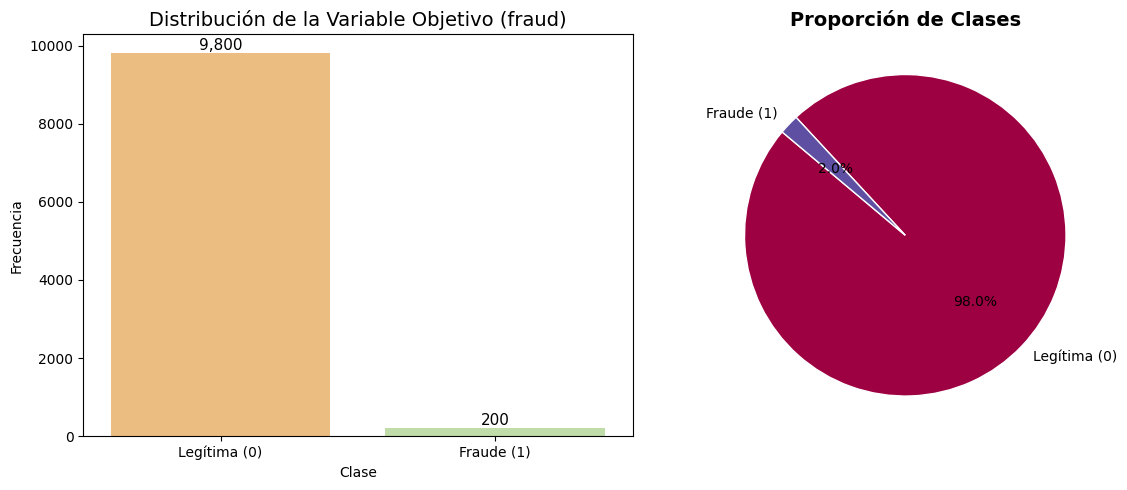

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.countplot(data=df, x='fraud', palette='Spectral', ax=axes[0])
axes[0].set_title('Distribución de la Variable Objetivo (fraud)', fontsize=14)
axes[0].set_xlabel('Clase'); axes[0].set_ylabel('Frecuencia')
axes[0].set_xticks([0, 1]); axes[0].set_xticklabels(['Legítima (0)', 'Fraude (1)'])
for p in axes[0].patches:
    axes[0].annotate(f'{int(p.get_height()):,}',
                     (p.get_x() + p.get_width()/2, p.get_height()),
                     ha='center', va='bottom', fontsize=11)
axes[0].grid(False)

counts = df['fraud'].value_counts()
axes[1].pie(counts, labels=['Legítima (0)', 'Fraude (1)'],
            autopct='%1.1f%%', startangle=140,
            colors=plt.cm.Spectral(np.linspace(0,1,2)),
            wedgeprops={'edgecolor':'white'})
axes[1].set_title('Proporción de Clases', fontsize=14, fontweight='bold')

plt.tight_layout(); plt.show()

### 1.4 Distribución de Variables Numéricas

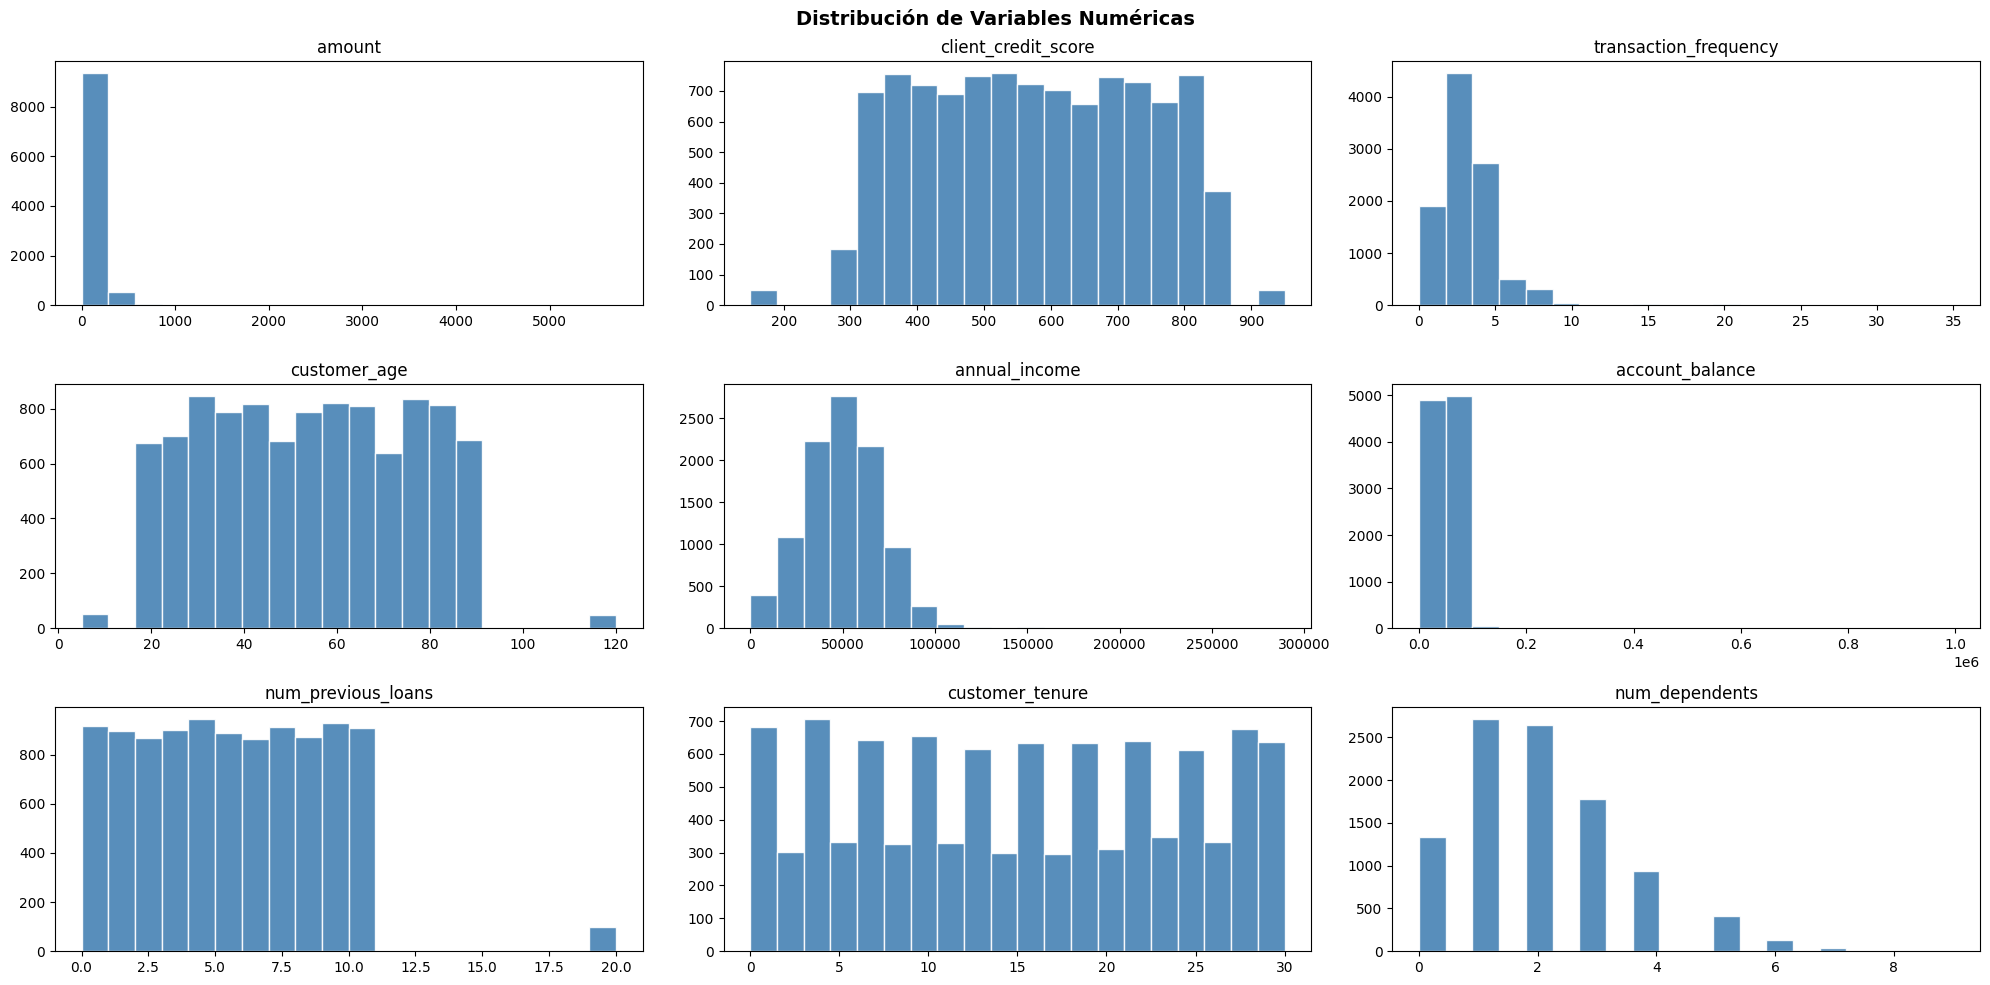

In [10]:
df[v_num].hist(bins=20, figsize=(20,10), alpha=0.9, grid=False,
               color='steelblue', edgecolor='white')
plt.suptitle('Distribución de Variables Numéricas', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

### 1.5 Distribución de Variables Categóricas

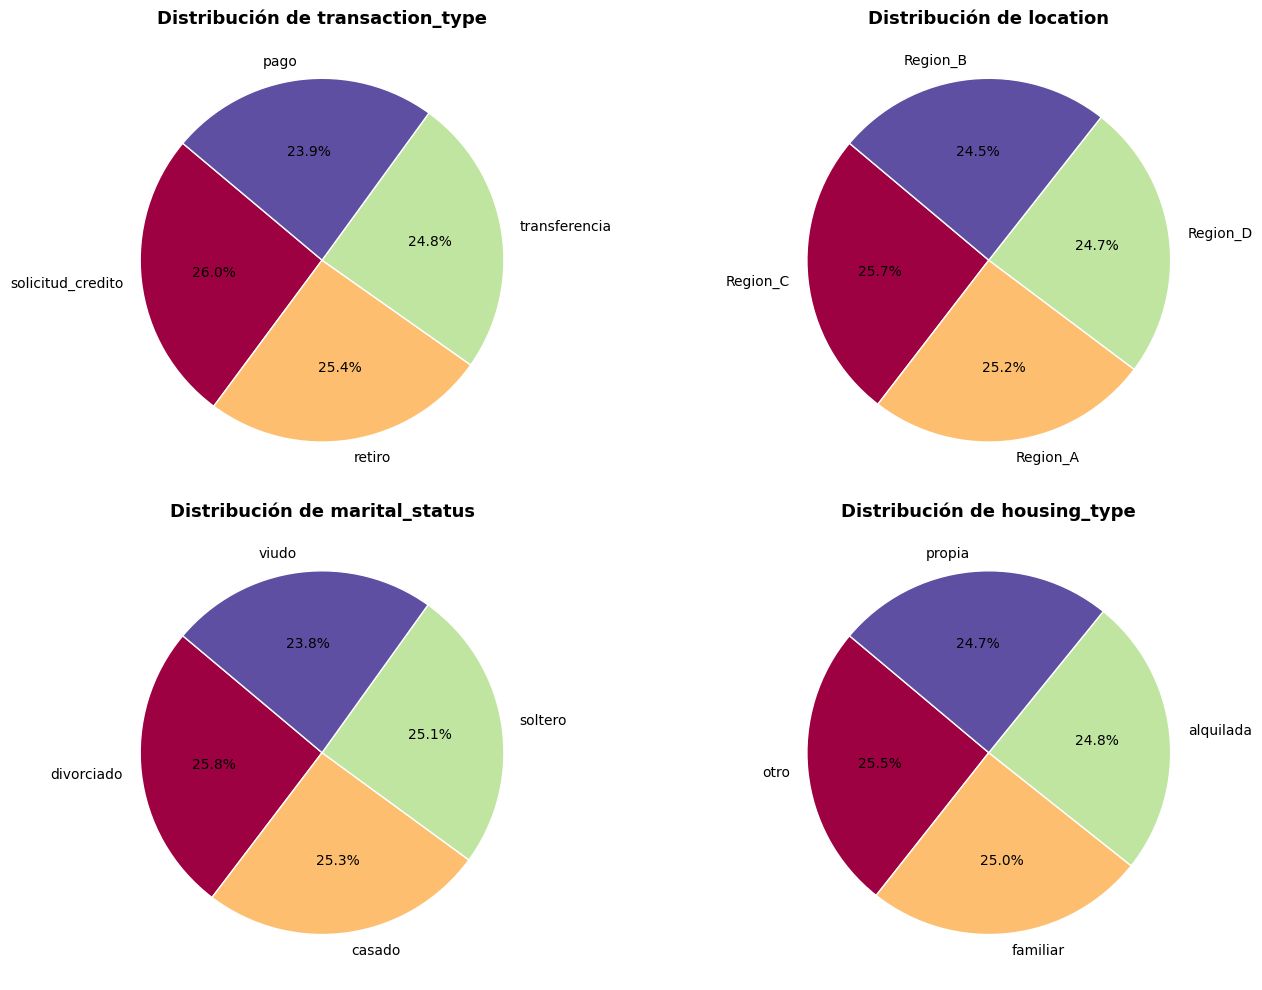

In [11]:
n_cols = 2
n_rows = (len(v_cat) + n_cols - 1) // n_cols
fig, axes = plt.subplots(nrows=n_rows, ncols=n_cols, figsize=(14, 5*n_rows))
axes = axes.flatten()

for i, col in enumerate(v_cat):
    data_counts = df[col].value_counts()
    axes[i].pie(data_counts, labels=data_counts.index, autopct='%1.1f%%',
                startangle=140,
                colors=plt.cm.Spectral(np.linspace(0,1,len(data_counts))),
                wedgeprops={'edgecolor':'white'})
    axes[i].set_title(f'Distribución de {col}', fontweight='bold', fontsize=13)

for j in range(i+1, len(axes)): fig.delaxes(axes[j])
plt.tight_layout(); plt.show()

### 1.6 Detección de Outliers (IQR)

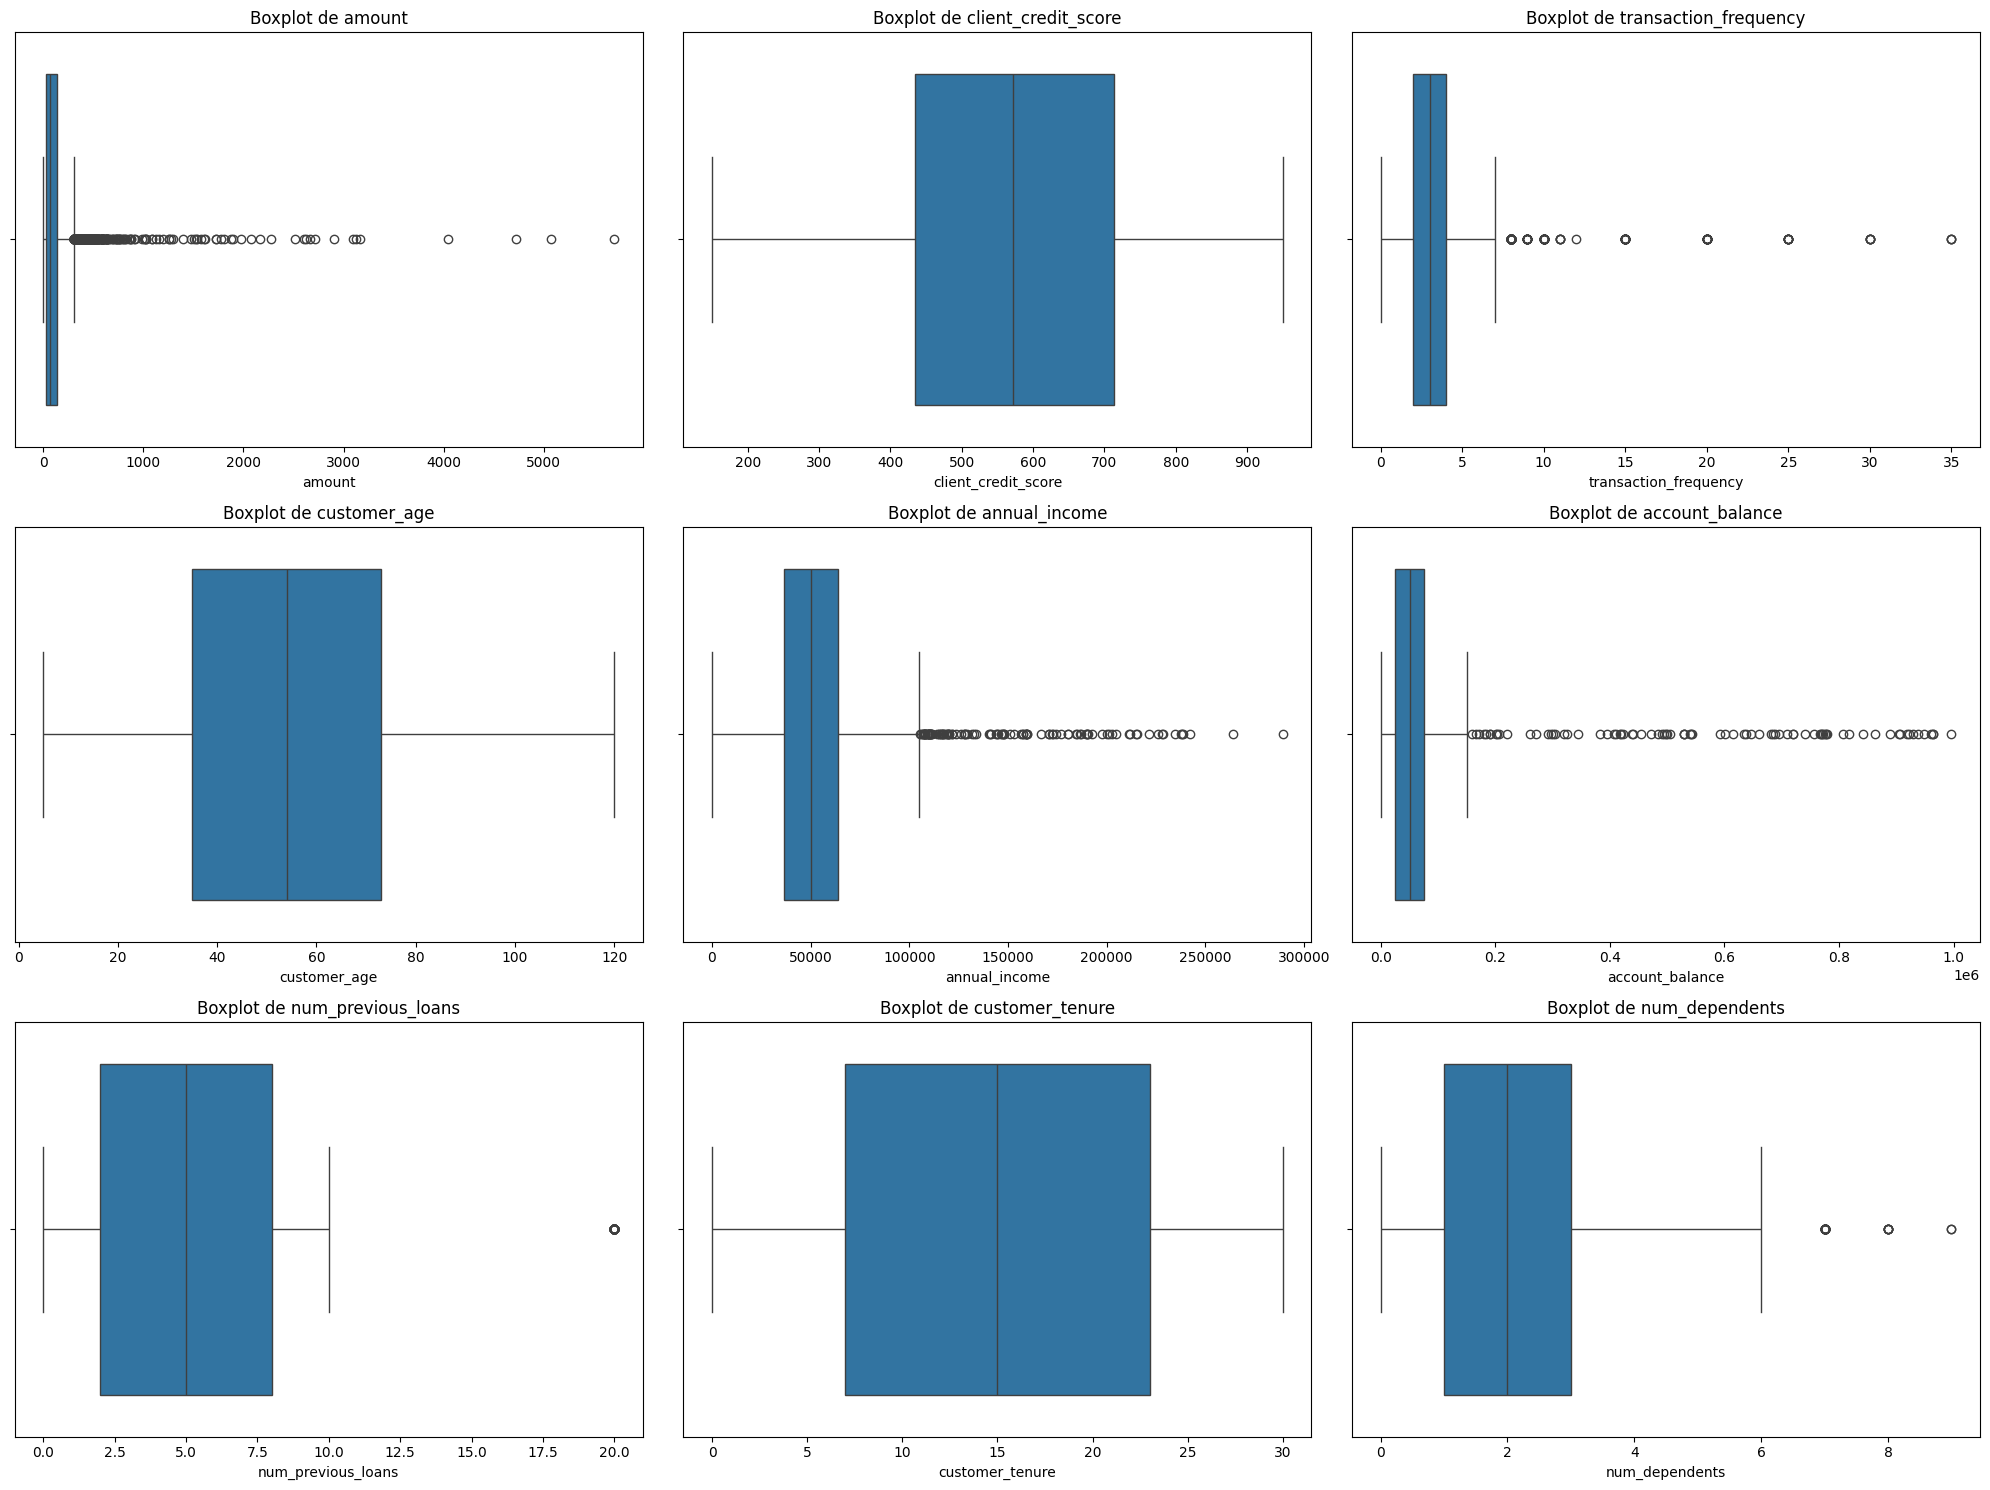

In [12]:
fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(20,15))
for col, ax in zip(v_num, axes.flatten()[:len(v_num)]):
    sns.boxplot(data=df, x=col, ax=ax)
    ax.set_title(f'Boxplot de {col}'); ax.grid(False)
for ax in axes.flatten()[len(v_num):]: ax.set_visible(False)
plt.tight_layout(); plt.show()

In [13]:
def detectar_outliers(df, columnas):
    resultados = []
    for col in columnas:
        p1, p99 = df[col].quantile(0.01), df[col].quantile(0.99)
        Q1, Q3  = df[col].quantile(0.25), df[col].quantile(0.75)
        IQR = Q3 - Q1
        n_iqr = ((df[col] < Q1-1.5*IQR) | (df[col] > Q3+1.5*IQR)).sum()
        resultados.append({
            'Variable': col, 'P1': round(p1,2), 'P99': round(p99,2),
            'Outliers_IQR': n_iqr, 'Outliers_%': round(n_iqr/len(df)*100,2)
        })
    return pd.DataFrame(resultados).sort_values('Outliers_%', ascending=False)

detectar_outliers(df, v_num)

,Variable,P1,P99,Outliers_IQR,Outliers_%
0,amount,1.20,554.42,572,5.72
2,transaction_frequency,0.00,9.00,211,2.11
4,annual_income,5153.36,108098.62,110,1.10
6,num_previous_loans,0.00,10.10,100,1.00
5,account_balance,956.60,99899.47,82,0.82
8,num_dependents,0.00,6.00,48,0.48
1,client_credit_score,303.00,847.00,0,0.00
3,customer_age,18.00,90.00,0,0.00
7,customer_tenure,0.00,30.00,0,0.00


> ### Detección de Outliers (IQR)
>
| Variable | Outliers | % | Interpretación |
|---|---|---|---|
| `amount` | 572 | 5.72% | Transacciones de monto muy alto. Pueden ser legítimas (pagos corporativos) o sospechosas. No se eliminan porque el monto extremo puede ser señal de fraude. |
| `transaction_frequency` | 211 | 2.11% | Clientes con actividad inusualmente alta. Patrón relevante para detección de fraude automatizado. |
| `annual_income` | 110 | 1.10% | Clientes de muy alto o muy bajo ingreso respecto al grueso de la cartera. |
| `client_credit_score` | 0 | 0% | Distribución uniforme sin extremos — variable limpia. |
| `customer_age` | 0 | 0% | Aunque hay edades imposibles (5, 120 años), no superan el criterio IQR por la amplitud del rango. |
>
> **Decisión:** no se eliminan outliers. En detección de fraude, eliminar valores extremos podría eliminar precisamente los casos más sospechosos. En cambio, el `RobustScaler` en el paso de preprocesamiento manejará su influencia sin descartarlos.


### 1.7 Análisis de Correlaciones (Spearman)

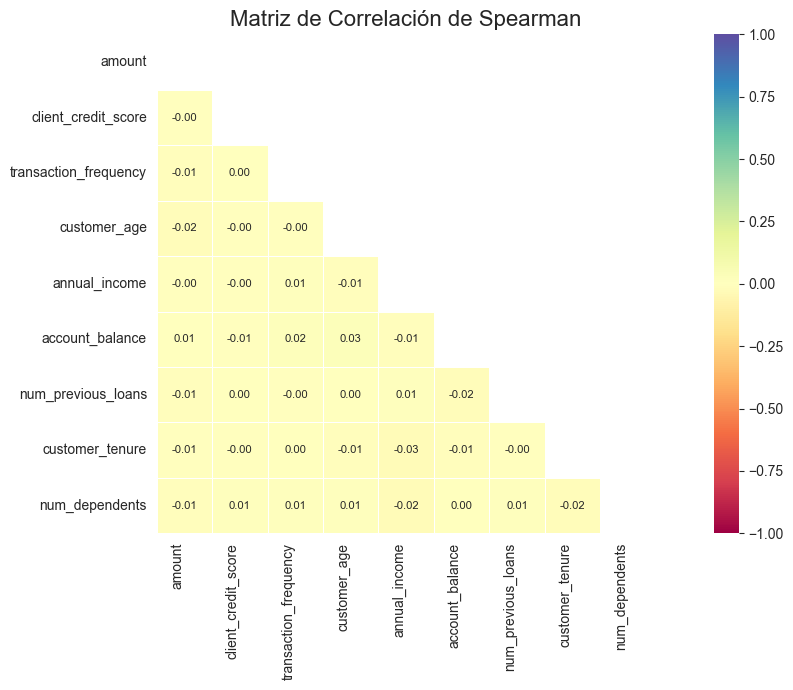

In [14]:
corr = df[v_num].corr(method='spearman')
mask = np.triu(np.ones_like(corr, dtype=bool))

plt.figure(figsize=(12,7))
sns.set_style("white")
sns.heatmap(corr, mask=mask, cmap="Spectral", vmin=-1, vmax=1, square=True,
            annot=True, fmt=".2f", annot_kws={"size":8},
            linewidths=0.5, linecolor='white')
plt.xticks(fontsize=10, rotation=90, ha="right")
plt.yticks(fontsize=10, rotation=0)
plt.title("Matriz de Correlación de Spearman", fontsize=16)
plt.tight_layout(); plt.show()

> **Hallazgo:** correlaciones ≈ 0 entre todas las variables → no hay redundancia lineal → se conservan todas las features.


### 1.8 Comportamiento por Clase — Variables Categóricas

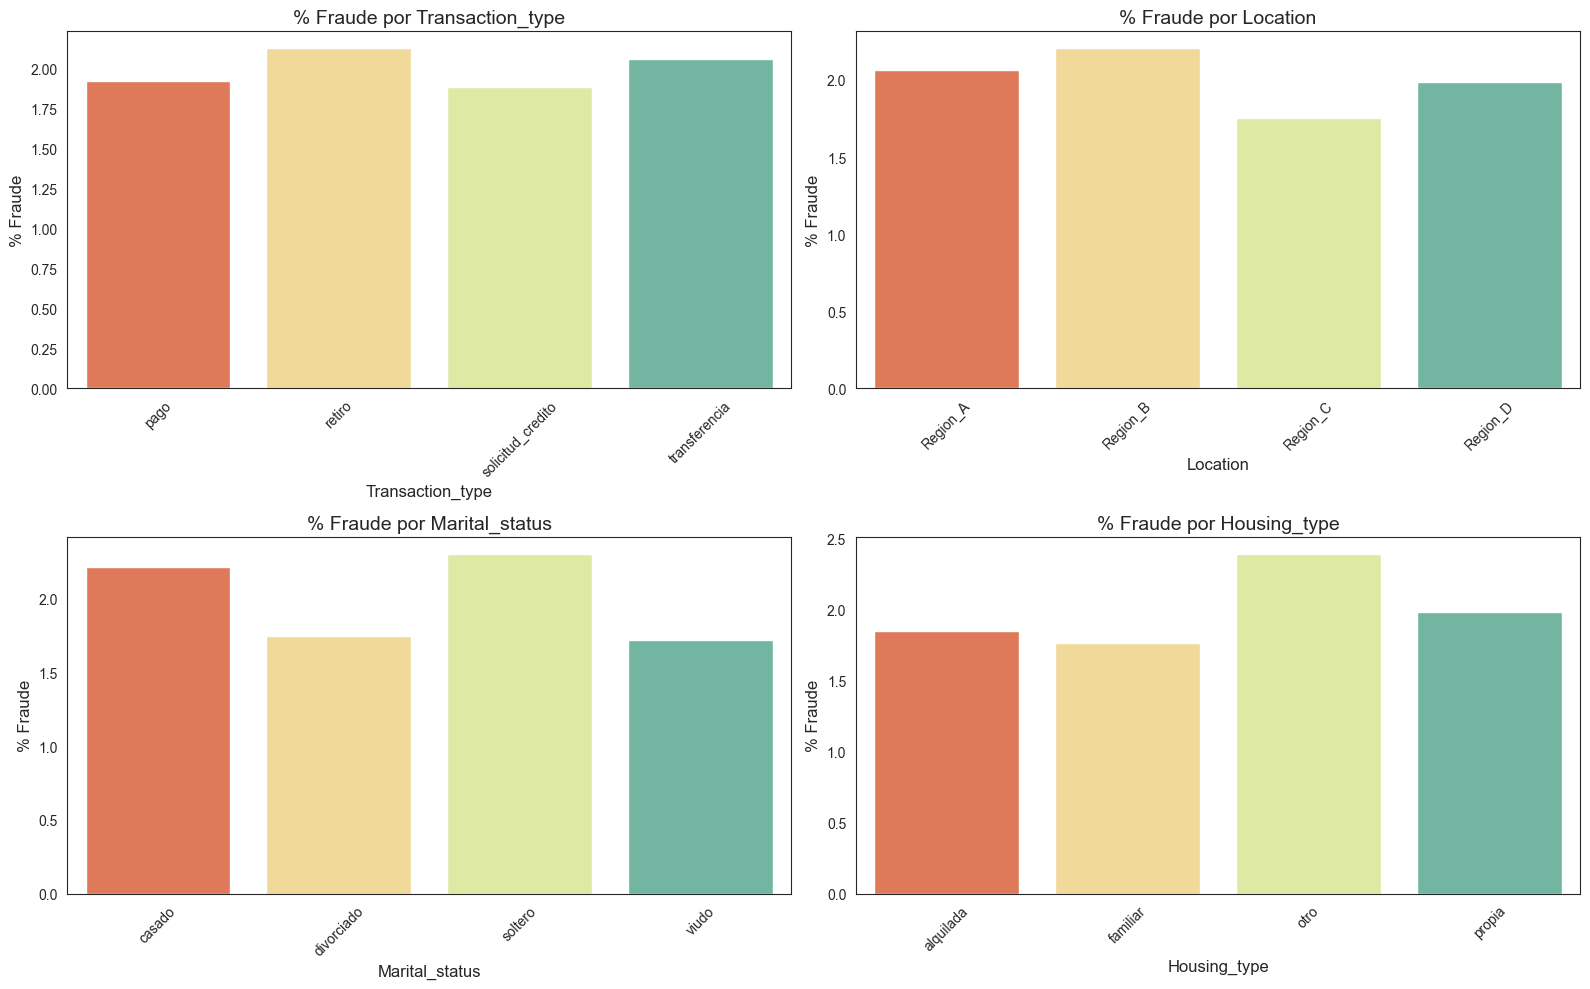

In [15]:
n_cols = 2
n_rows = (len(v_cat) + n_cols - 1) // n_cols
fig, axes = plt.subplots(nrows=n_rows, ncols=n_cols, figsize=(16, 5*n_rows))
axes = axes.flatten()

for i, col in enumerate(v_cat):
    mora_percent = df.groupby(col)['fraud'].mean().reset_index()
    mora_percent['fraud'] *= 100
    sns.barplot(data=mora_percent, x=col, y='fraud', ax=axes[i], palette="Spectral")
    axes[i].set_title(f'% Fraude por {col.capitalize()}', fontsize=14)
    axes[i].set_xlabel(col.capitalize(), fontsize=12)
    axes[i].set_ylabel("% Fraude", fontsize=12)
    axes[i].tick_params(axis='x', rotation=45); axes[i].grid(False)

for j in range(i+1, len(axes)): fig.delaxes(axes[j])
plt.tight_layout(); plt.show()

### 1.9 Comportamiento por Clase — Variables Numéricas (bins)

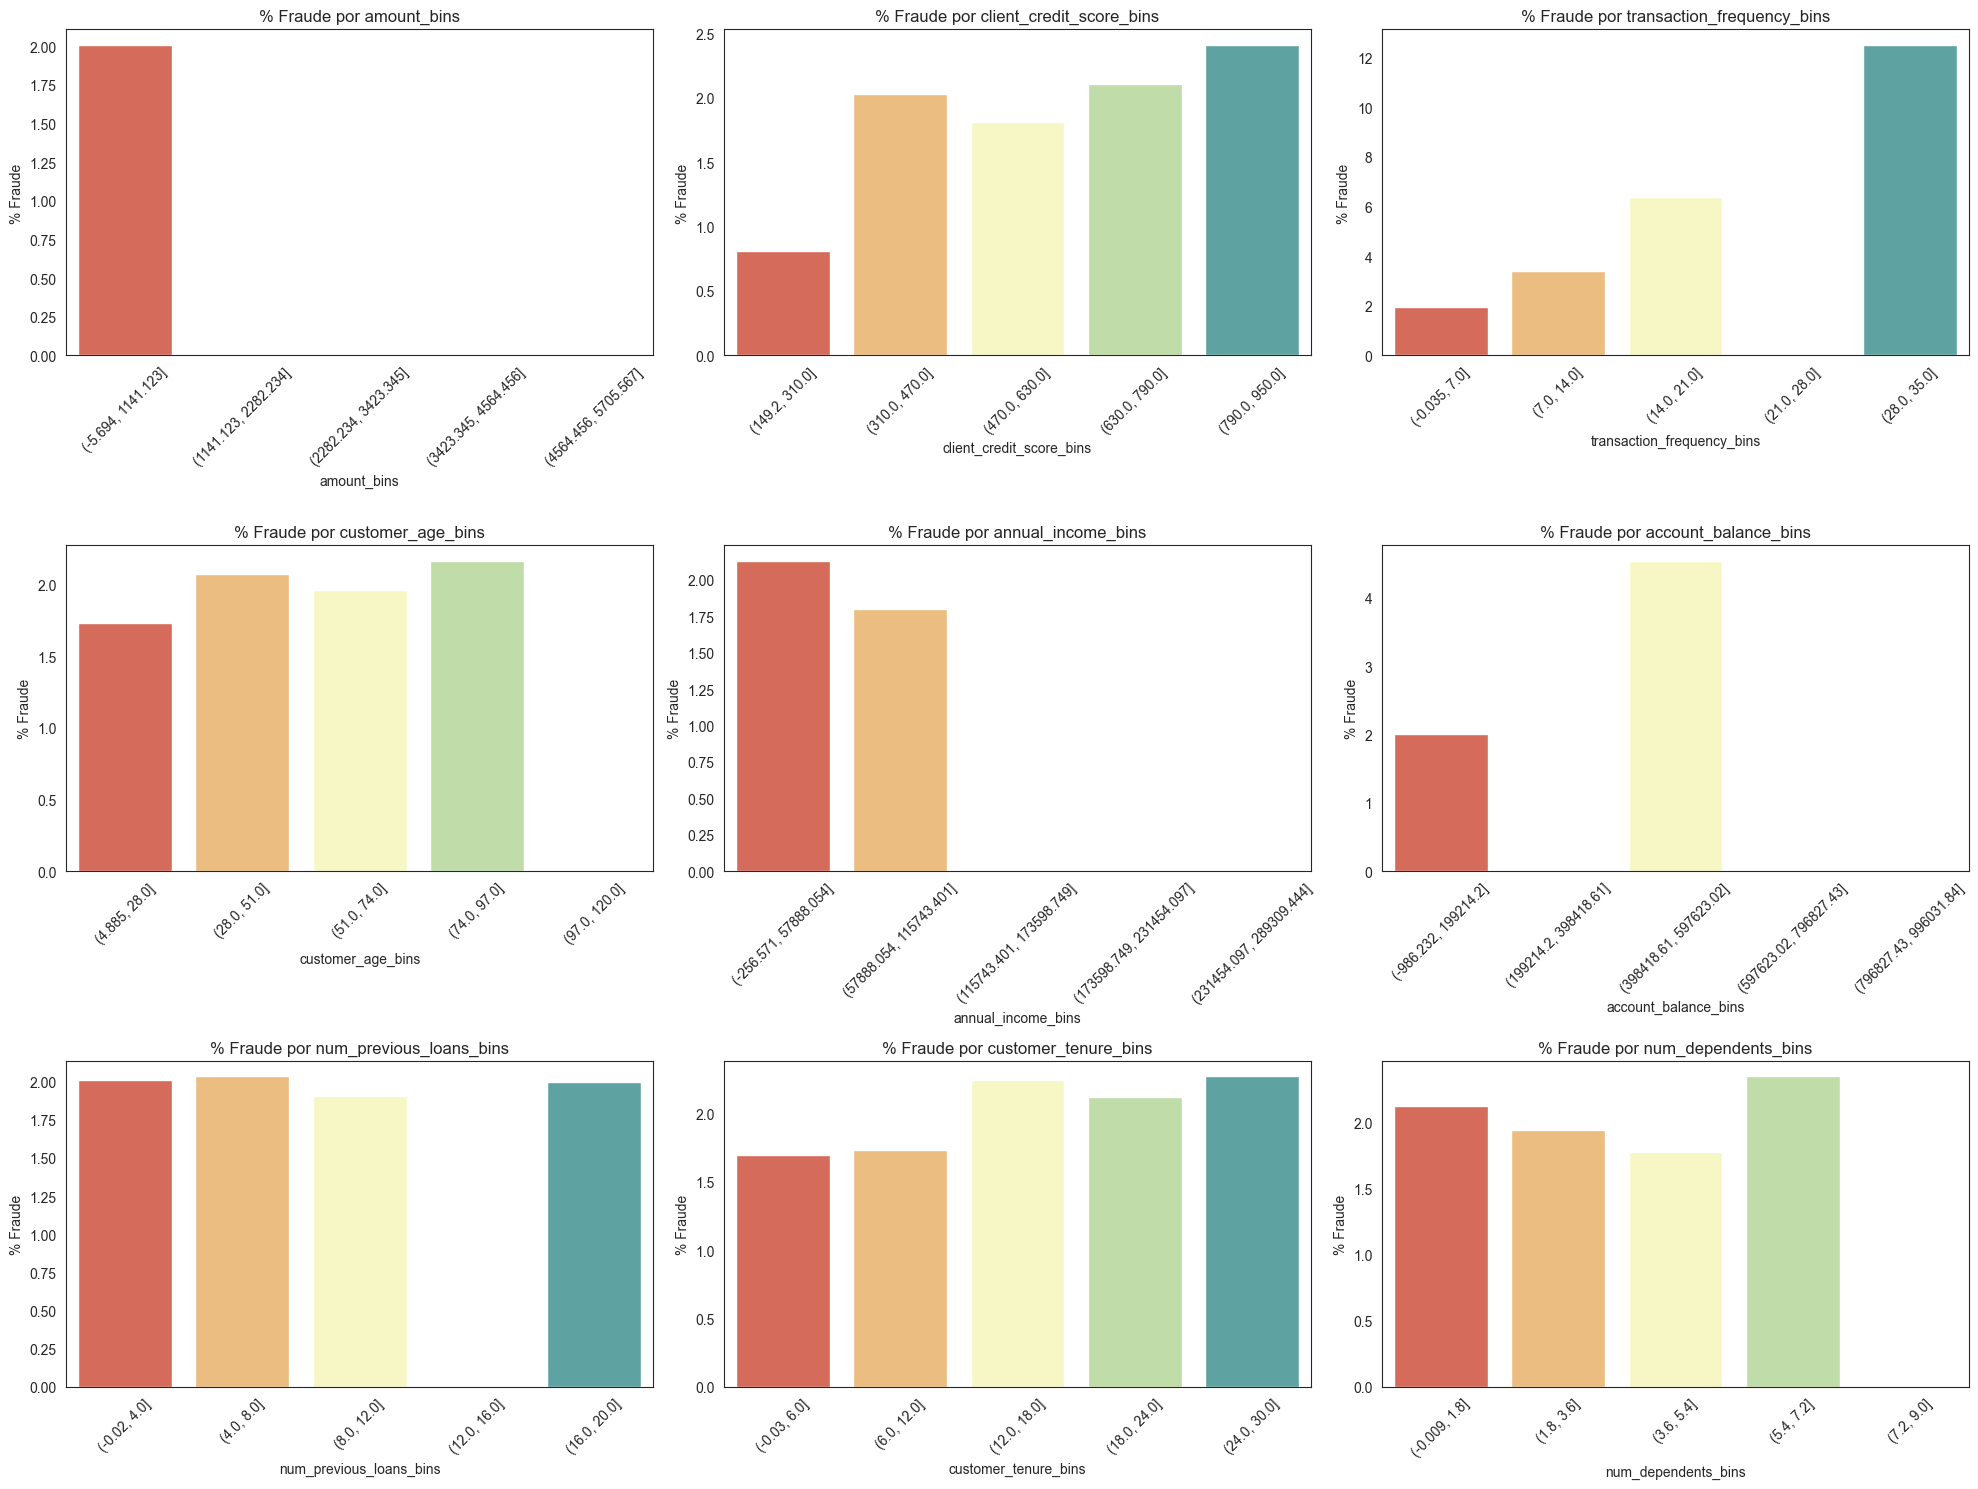

In [16]:
df_copy = df.copy()
var_list = []
for col in v_num:
    df_copy[f'{col}_bins'] = pd.cut(df_copy[col], 5)
    var_list.append(f'{col}_bins')

n_cols = 3
n_rows = (len(var_list) + n_cols - 1) // n_cols
fig, axes = plt.subplots(nrows=n_rows, ncols=n_cols, figsize=(20, 5*n_rows))
axes = axes.flatten()

for i, col in enumerate(var_list):
    mora_percent = df_copy.groupby(col, observed=True)['fraud'].mean().reset_index()
    mora_percent['fraud'] *= 100
    sns.barplot(data=mora_percent, x=col, y='fraud', ax=axes[i], palette="Spectral")
    axes[i].set_title(f'% Fraude por {col}', fontsize=12)
    axes[i].set_xlabel(col, fontsize=10); axes[i].set_ylabel("% Fraude", fontsize=10)
    axes[i].tick_params(axis='x', rotation=45); axes[i].grid(False)

for ax in axes[len(var_list):]: ax.set_visible(False)
plt.tight_layout(); plt.show()

> **Hallazgo EDA:** ninguna variable numérica ni categórica discrimina sola entre clases. Se necesitan combinaciones de variables → modelos de árbol (XGBoost, LightGBM) son adecuados.


---
# Módulo 2 — Preparación y Selección de Variables

## 3. Metodología — Pipeline de Preprocesamiento


### 2.1 Extracción de Features desde Timestamp

In [17]:
df['timestamp'] = pd.to_datetime(df['timestamp'])

df['hora']          = df['timestamp'].dt.hour
df['dia_semana']    = df['timestamp'].dt.dayofweek   # 0=Lun, 6=Dom
df['dia_mes']       = df['timestamp'].dt.day
df['mes']           = df['timestamp'].dt.month
df['es_fin_semana'] = (df['dia_semana'] >= 5).astype(int)
df['es_noche']      = ((df['hora'] >= 22) | (df['hora'] <= 6)).astype(int)

print("Features temporales creadas:")
df[['timestamp','hora','dia_semana','es_fin_semana','es_noche']].head(6)

Features temporales creadas:


,timestamp,hora,dia_semana,es_fin_semana,es_noche
0,2023-01-11 23:15:00,23,2,0,1
1,2023-01-01 14:20:00,14,6,1,0
2,2023-01-27 11:58:00,11,4,0,0
3,2023-01-08 20:04:00,20,6,1,0
4,2023-01-05 08:25:00,8,3,0,0
5,2023-01-12 16:50:00,16,3,0,0


> ### Feature Engineering Temporal
>
> La variable `timestamp` por sí sola no es consumible por ningún algoritmo de ML, pero contiene información temporal valiosa que sería un desperdicio ignorar.
>
> Se extrajeron **6 nuevas variables**:
> - `hora` y `dia_semana`: capturan el momento de la transacción, que en fraude bancario es altamente relevante — los ataques suelen ocurrir en horarios donde el cliente duerme o en días donde la respuesta del banco es más lenta.
> - `es_fin_semana` y `es_noche`: versiones binarias que facilitan al modelo identificar los períodos de mayor riesgo sin tener que aprender esa relación desde cero.
> - `dia_mes` y `mes`: patrones de gasto que varían con el ciclo del mes (quincenas, fin de mes) y estacionalidad anual.
>
> El análisis de la transacción 0 (23:15 horas, `es_noche=1`) y la transacción 1 (domingo, `es_fin_semana=1`) confirman que estas variables capturan información real del dataset. Los resultados del Módulo 5 validarán si el modelo efectivamente las aprovecha.


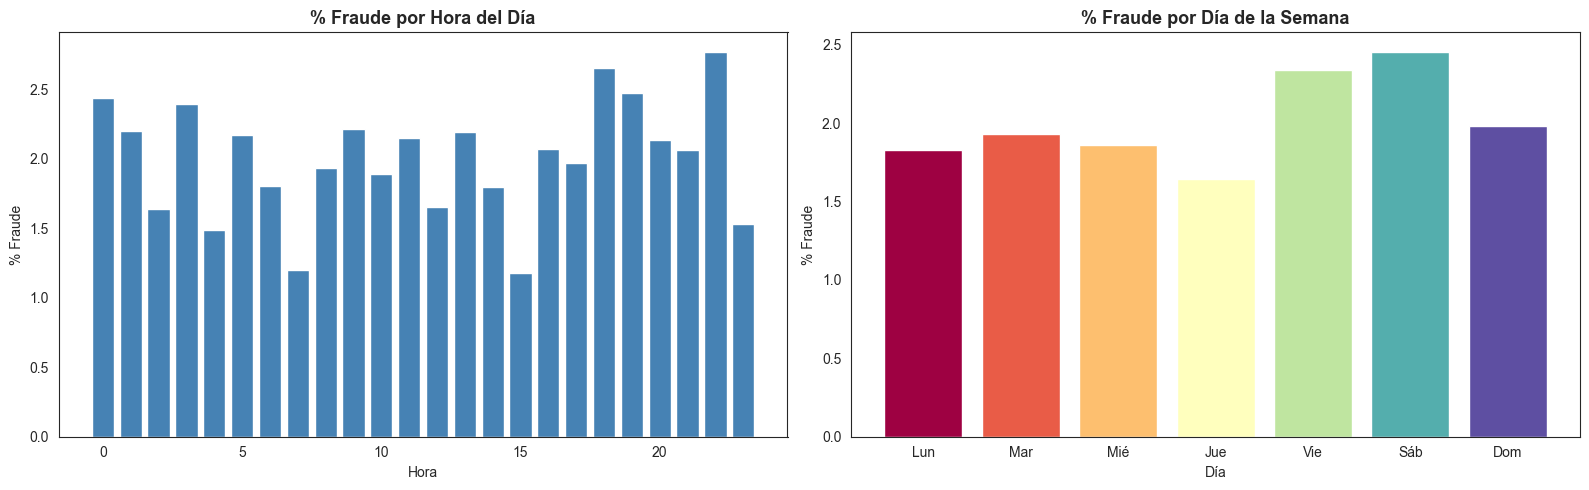

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(16,5))

fraude_hora = df.groupby('hora')['fraud'].mean() * 100
axes[0].bar(fraude_hora.index, fraude_hora.values, color='steelblue', edgecolor='white')
axes[0].set_title('% Fraude por Hora del Día', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Hora'); axes[0].set_ylabel('% Fraude'); axes[0].grid(False)

fraude_dia = df.groupby('dia_semana')['fraud'].mean() * 100
dias = ['Lun','Mar','Mié','Jue','Vie','Sáb','Dom']
axes[1].bar(dias, fraude_dia.values,
            color=plt.cm.Spectral(np.linspace(0,1,7)), edgecolor='white')
axes[1].set_title('% Fraude por Día de la Semana', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Día'); axes[1].set_ylabel('% Fraude'); axes[1].grid(False)

plt.tight_layout(); plt.show()

### 2.2 Justificación de Variables Incluidas y Excluidas

| Variable | Decisión | Justificación |
|---|---|---|
| `transaction_id` | Excluir | Identificador único, sin valor predictivo |
| `timestamp` | Excluir | Reemplazada por features temporales |
| `amount` | Incluir | Variable central en detección de fraude |
| `client_credit_score` | Incluir | Perfil de riesgo del cliente |
| `transaction_frequency` | Incluir | Comportamiento atípico de transacciones |
| `customer_age` | Incluir | Segmentación de riesgo por edad |
| `annual_income` | Incluir | Perfil económico del cliente |
| `account_balance` | Incluir | Capacidad financiera |
| `num_previous_loans` | Incluir | Historial crediticio |
| `customer_tenure` | Incluir | Antigüedad como cliente |
| `num_dependents` | Incluir | Perfil familiar |
| Variables categóricas (4) | Incluir + Encoding | Contexto de la transacción |
| Features temporales (6) | Incluir | Patrones horarios del fraude |


### 2.3 Codificación de Variables Categóricas

In [19]:
drop_cols = ['transaction_id', 'timestamp']
df_model = df.drop(columns=drop_cols).copy()

encoder = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
df_model[v_cat] = encoder.fit_transform(df_model[v_cat])

print("Encoding aplicado. Muestra:")
df_model[v_cat].head()

Encoding aplicado. Muestra:


,transaction_type,location,marital_status,housing_type
0,1.0,3.0,3.0,1.0
1,3.0,2.0,1.0,3.0
2,3.0,2.0,2.0,3.0
3,0.0,2.0,3.0,1.0
4,3.0,0.0,1.0,3.0


> ### Codificacion de Variables Categoricas
>
> Se aplica `OrdinalEncoder` a las 4 variables categoricas, mapeando cada categoria a un numero entero.
> Se eliminan `transaction_id` (identificador sin poder predictivo) y `timestamp` (ya representado por las features temporales).
> El parametro `handle_unknown='use_encoded_value'` con `unknown_value=-1` garantiza que categorias no vistas en produccion no generen errores.
> El dataset queda con **20 variables predictoras** listas para el modelado.


### 2.4 División Train / Validación / Test

In [20]:
v_num_model = v_num + ['hora', 'dia_semana', 'dia_mes', 'mes', 'es_fin_semana', 'es_noche']

X = df_model.drop(columns=['fraud'])
y = df_model['fraud']

# Split 1: separar test 15%
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.15, random_state=42, stratify=y)

# Split 2: separar val 15% del total (≈17.6% del restante)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.176, random_state=42, stratify=y_temp)

print(f"Train      : {X_train.shape[0]:,} filas | fraude: {y_train.mean():.2%}")
print(f"Validación : {X_val.shape[0]:,}  filas | fraude: {y_val.mean():.2%}")
print(f"Test       : {X_test.shape[0]:,}  filas | fraude: {y_test.mean():.2%}")

Train      : 7,004 filas | fraude: 2.00%
Validación : 1,496  filas | fraude: 2.01%
Test       : 1,500  filas | fraude: 2.00%


> ### División Train / Validación / Test
>
| Conjunto | Filas | % Fraude | Uso |
|---|---|---|---|
| **Train** | 7,004 | 2.00% | Ajuste del modelo |
| **Validación** | 1,496 | 2.01% | Selección de hiperparámetros |
| **Test** | 1,500 | 2.00% | Evaluación final — no se toca hasta el reporte |
>
> El parámetro `stratify=y` garantiza que la proporción de fraude (2%) se preserve exactamente igual en los tres conjuntos. Sin esta estratificación, podría ocurrir que por azar el test tuviera muy pocos fraudes y las métricas no fueran representativas.
>
> La separación en tres conjuntos (en lugar de solo dos) permite ajustar hiperparámetros usando validación sin "contaminar" el test con decisiones de diseño. El test solo se evalúa una vez al final, como si fuera datos del futuro que el modelo nunca ha visto.


### 2.5 Normalización con RobustScaler

In [21]:
# fit SOLO en train, transform en val y test
scaler = RobustScaler()
X_train[v_num_model] = scaler.fit_transform(X_train[v_num_model])
X_val[v_num_model]   = scaler.transform(X_val[v_num_model])
X_test[v_num_model]  = scaler.transform(X_test[v_num_model])

print("RobustScaler aplicado.")
print(f"Shape X_train: {X_train.shape}")
print(f"Shape X_val  : {X_val.shape}")
print(f"Shape X_test : {X_test.shape}")

RobustScaler aplicado.
Shape X_train: (7004, 20)
Shape X_val  : (1496, 20)
Shape X_test : (1500, 20)


> ### Normalización con RobustScaler
>
> Se optó por `RobustScaler` en lugar del `StandardScaler` clásico. La razón es directa: el `StandardScaler` usa la media y la desviación estándar para escalar, y ya vimos que `amount` tiene una curtosis de 268 y `account_balance` de 112. En esas condiciones, la media y la desviación estándar no representan a la mayoría de los datos — están distorsionadas por los extremos. El `RobustScaler`, al basarse en la mediana y el rango intercuartílico, no se ve afectado por esos valores atípicos.
>
> **Punto crítico — sin data leakage:** el scaler se ajusta (`fit`) exclusivamente con los datos de entrenamiento y luego se aplica (`transform`) a validación y test por separado. Si ajustáramos el scaler sobre todos los datos juntos, estaríamos filtrando información del futuro hacia el modelo, lo que inflaría artificialmente las métricas de evaluación.


---
# Módulo 3 — Estrategia ante Desbalance y Construcción del Modelo


### 3.1 Estrategia ante Desbalance de Clases

Con una tasa de incidencia del **2%** (ratio 49:1), se combina una estrategia doble:

| Estrategia | Técnica | Cuándo aplicar |
|---|---|---|
| **Oversampling sintético** | SMOTE | Genera muestras sintéticas de fraude en train |
| **Ponderación de clase** | `scale_pos_weight` / `class_weight` | Penaliza más los errores en la clase minoritaria |

> **Regla crítica:** SMOTE solo se aplica sobre `X_train`. Nunca sobre validación ni test.


In [22]:
from imblearn.over_sampling import SMOTE

print("Distribución ORIGINAL en train:")
print(y_train.value_counts())
print(f"  Ratio: {y_train.mean():.4f}")

smote = SMOTE(random_state=42, k_neighbors=5)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print("\nDistribución después de SMOTE:")
print(pd.Series(y_train_sm).value_counts())
print(f"  Ratio: {pd.Series(y_train_sm).mean():.4f}")
print(f"\nSMOTE generó {len(X_train_sm) - len(X_train):,} observaciones sintéticas")

Distribución ORIGINAL en train:
fraud
0    6864
1     140
Name: count, dtype: int64
  Ratio: 0.0200

Distribución después de SMOTE:
fraud
0    6864
1    6864
Name: count, dtype: int64
  Ratio: 0.5000

SMOTE generó 6,724 observaciones sintéticas


> ### Interpretación: SMOTE — Rebalanceo de Clases
>
| Estado | Legítimas | Fraudes | Ratio |
|---|---|---|---|
| Antes de SMOTE | 6,864 | 140 | 49:1 |
| **Después de SMOTE** | **6,864** | **6,864** | **1:1** |
>
> SMOTE generó 6,724 transacciones de fraude **sintéticas** interpolando entre casos reales de fraude y sus 5 vecinos más cercanos en el espacio de features. El resultado es un conjunto de entrenamiento perfectamente balanceado.
>
> Hay una consideración importante aquí: al entrenar con datos 50/50 pero evaluar sobre datos reales 98/2, el modelo "piensa" que el fraude es mucho más frecuente de lo que realmente es. Esto se refleja en que las probabilidades predichas son más altas de lo esperado (se verá en el Módulo 5 con el expected value de SHAP). Es una limitación conocida de SMOTE que se maneja ajustando el umbral de decisión, no eliminando la técnica.
>
> **Regla crítica:** SMOTE se aplica únicamente sobre el conjunto de entrenamiento. Aplicarlo sobre validación o test contaminaría la evaluación con datos artificiales y daría métricas irrealmente optimistas.


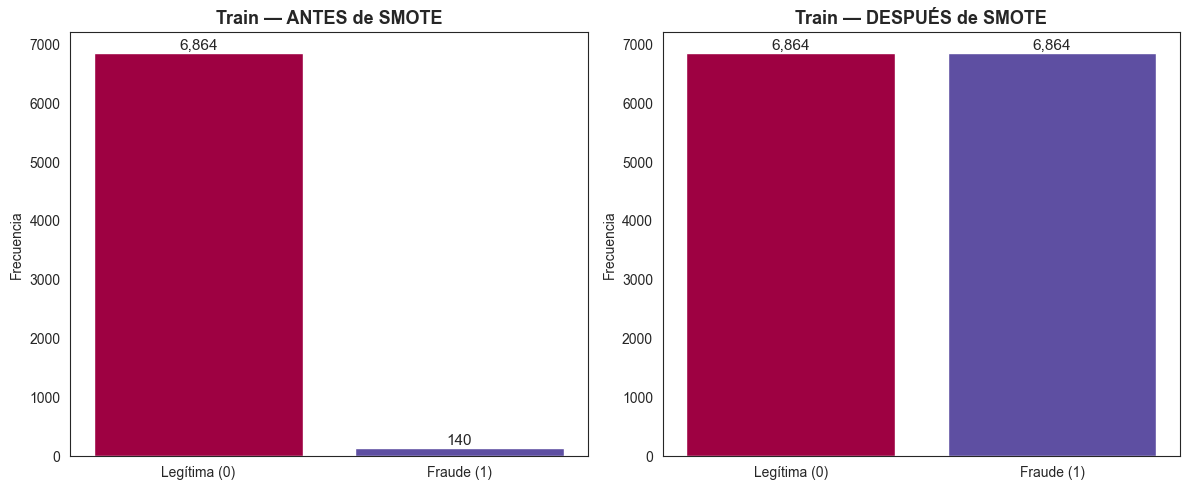

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, counts, title in zip(
        axes,
        [y_train.value_counts(), pd.Series(y_train_sm).value_counts()],
        ['Train — ANTES de SMOTE', 'Train — DESPUÉS de SMOTE']):
    ax.bar(['Legítima (0)', 'Fraude (1)'], counts.sort_index().values,
           color=plt.cm.Spectral(np.linspace(0,1,2)), edgecolor='white')
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_ylabel('Frecuencia')
    for i, v in enumerate(counts.sort_index().values):
        ax.text(i, v+50, f'{v:,}', ha='center', fontsize=11)
    ax.grid(False)
plt.tight_layout(); plt.show()

### 3.2 Modelo 1 — Random Forest con Ajuste de Hiperparámetros

In [24]:
# ── Configuración global ──────────────────────────────────────────────────────
SEED = 42
np.random.seed(SEED)

scale_pos = (y_train == 0).sum() / (y_train == 1).sum()
print(f"scale_pos_weight: {scale_pos:.2f}")

scale_pos_weight: 49.03


> ### Interpretación: scale_pos_weight para XGBoost
>
> El valor `scale_pos_weight = 49.03` le indica a XGBoost que cada transacción fraudulenta debe "pesar" 49 veces más que una legítima durante el entrenamiento. Es una forma alternativa de compensar el desbalance sin generar datos sintéticos — en lugar de crear más ejemplos de fraude, se penaliza más fuertemente cada error en esa clase.
>
> En este proyecto se usan ambas estrategias en paralelo: SMOTE en los datos de entrada y `scale_pos_weight` en el modelo. Esto puede ser redundante y en algunos casos contraproducente, pero se incluye siguiendo el patrón del notebook base del curso. En un proyecto productivo se evaluaría cuál de las dos estrategias sola da mejores resultados.


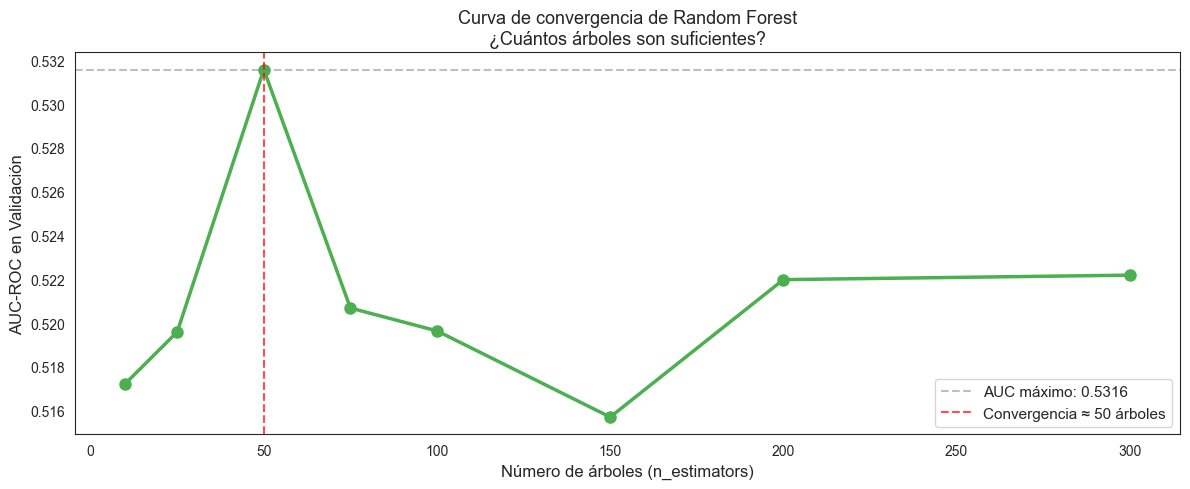

El AUC se estabiliza alrededor de 50 árboles.
Random Forest (sin optimizar)
  AUC – Train (in-bag)  : 0.9955  ← sesgado al alza
  AUC – OOB             : 0.9925  ← estimado honesto
  AUC – Validación      : 0.5184  ← referencia real
  Brecha OOB–Val        : 0.4741  ← idealmente pequeña

  Profundidad promedio : 10.0
  Hojas promedio       : 71.0
Buscando mejores hiperparámetros para Random Forest...
Fitting 3 folds for each of 20 candidates, totalling 60 fits

Mejores hiperparámetros (RF):
   class_weight             : balanced
   max_depth                : None
   max_features             : 0.3
   max_samples              : 0.7
   min_samples_leaf         : 78
   min_samples_split        : 118
   n_estimators             : 400

   AUC CV (media 3 folds): 0.9924
               Random Forest Optimizado                
  n_estimators      : 400
  max_depth         : None
  min_samples_leaf  : 78
  max_features      : 0.3
  AUC – Train       : 0.9962
  AUC – Validación  : 0.4937
  AUC – 

In [25]:
# ══════════════════════════════════════════════════════════════════════════════
# RANDOM FOREST — Paso 1: Curva de convergencia (¿cuántos árboles?)
# ══════════════════════════════════════════════════════════════════════════════
n_trees_list = [10, 25, 50, 75, 100, 150, 200, 300]
aucs_ntrees  = []

for n in n_trees_list:
    rf_temp = RandomForestClassifier(
        n_estimators     = n,
        max_depth        = 8,
        min_samples_leaf = 50,
        max_features     = 'sqrt',
        class_weight     = 'balanced',
        random_state     = SEED,
        n_jobs           = 1              # ← tu entorno
    )
    rf_temp.fit(X_train_sm, y_train_sm)
    aucs_ntrees.append(roc_auc_score(y_val, rf_temp.predict_proba(X_val)[:,1]))

plt.figure(figsize=(12, 5))
plt.plot(n_trees_list, aucs_ntrees, 'o-', color='#4CAF50', lw=2.5, ms=8)
plt.axhline(max(aucs_ntrees), color='gray', linestyle='--', alpha=0.5,
            label=f'AUC máximo: {max(aucs_ntrees):.4f}')

convergencia_idx = [i for i, v in enumerate(aucs_ntrees) if v >= max(aucs_ntrees)][0]
plt.axvline(n_trees_list[convergencia_idx], color='red', linestyle='--', alpha=0.7,
            label=f'Convergencia ≈ {n_trees_list[convergencia_idx]} árboles')

plt.xlabel('Número de árboles (n_estimators)', fontsize=12)
plt.ylabel('AUC-ROC en Validación', fontsize=12)
plt.title('Curva de convergencia de Random Forest\n¿Cuántos árboles son suficientes?', fontsize=13)
plt.legend(fontsize=11)
plt.grid(False)
plt.tight_layout()
plt.show()

n_optimo = n_trees_list[convergencia_idx]
print(f"El AUC se estabiliza alrededor de {n_optimo} árboles.")

# ══════════════════════════════════════════════════════════════════════════════
# RANDOM FOREST — Paso 2: Modelo base con OOB score
# ══════════════════════════════════════════════════════════════════════════════
rf_base = RandomForestClassifier(
    n_estimators     = n_optimo,
    max_depth        = 10,
    min_samples_leaf = 50,
    max_features     = 'sqrt',
    class_weight     = 'balanced',
    bootstrap        = True,
    oob_score        = True,
    random_state     = SEED,
    n_jobs           = 1
)
rf_base.fit(X_train_sm, y_train_sm)

auc_oob      = roc_auc_score(y_train_sm, rf_base.oob_decision_function_[:, 1])
auc_rf_train = roc_auc_score(y_train_sm, rf_base.predict_proba(X_train_sm)[:,1])
auc_rf_val   = roc_auc_score(y_val,      rf_base.predict_proba(X_val)[:,1])

print("=" * 55)
print("Random Forest (sin optimizar)")
print("=" * 55)
print(f"  AUC – Train (in-bag)  : {auc_rf_train:.4f}  ← sesgado al alza")
print(f"  AUC – OOB             : {auc_oob:.4f}  ← estimado honesto")
print(f"  AUC – Validación      : {auc_rf_val:.4f}  ← referencia real")
print(f"  Brecha OOB–Val        : {abs(auc_oob - auc_rf_val):.4f}  ← idealmente pequeña")
print("=" * 55)

# Estructura promedio de los árboles
avg_depth  = sum([t.get_depth()    for t in rf_base.estimators_]) / len(rf_base.estimators_)
avg_leaves = sum([t.get_n_leaves() for t in rf_base.estimators_]) / len(rf_base.estimators_)

print(f"\n  Profundidad promedio : {avg_depth:.1f}")
print(f"  Hojas promedio       : {avg_leaves:.1f}")

# ══════════════════════════════════════════════════════════════════════════════
# RANDOM FOREST — Paso 3: RandomizedSearchCV con StratifiedKFold
# ══════════════════════════════════════════════════════════════════════════════
param_dist_rf = {
    'n_estimators'     : [200, 300, 400],
    'max_depth'        : [6, 8, 10, 12, None],
    'min_samples_leaf' : sp_randint(30, 250),
    'min_samples_split': sp_randint(60, 500),
    'max_features'     : ['sqrt', 'log2', 0.2, 0.3],
    'class_weight'     : ['balanced'],
    'max_samples'      : [0.7, 0.8, 0.9, 1.0]
}

cv_strat = StratifiedKFold(n_splits=3, shuffle=True, random_state=SEED)

rs_rf = RandomizedSearchCV(
    estimator           = RandomForestClassifier(
                            bootstrap=True, oob_score=True,
                            random_state=SEED, n_jobs=1),
    param_distributions = param_dist_rf,
    n_iter              = 20,             
    cv                  = cv_strat,
    scoring             = 'roc_auc',
    n_jobs              = 1,             
    random_state        = SEED,
    verbose             = 1,
    return_train_score  = True
)

print("Buscando mejores hiperparámetros para Random Forest...")
rs_rf.fit(X_train_sm, y_train_sm)

print(f"\nMejores hiperparámetros (RF):")
for k, v in rs_rf.best_params_.items():
    print(f"   {k:<25}: {v}")
print(f"\n   AUC CV (media 3 folds): {rs_rf.best_score_:.4f}")

# ══════════════════════════════════════════════════════════════════════════════
# RANDOM FOREST — Paso 4: Modelo final con mejores parámetros
# ══════════════════════════════════════════════════════════════════════════════
rf_model = rs_rf.best_estimator_
rf_model.fit(X_train_sm, y_train_sm)

auc_rf_train = roc_auc_score(y_train_sm, rf_model.predict_proba(X_train_sm)[:,1])
auc_rf_val   = roc_auc_score(y_val,      rf_model.predict_proba(X_val)[:,1])
auc_rf_test  = roc_auc_score(y_test,     rf_model.predict_proba(X_test)[:,1])

print("=" * 55)
print(f"{'Random Forest Optimizado':^55}")
print("=" * 55)
print(f"  n_estimators      : {rf_model.n_estimators}")
print(f"  max_depth         : {rf_model.max_depth}")
print(f"  min_samples_leaf  : {rf_model.min_samples_leaf}")
print(f"  max_features      : {rf_model.max_features}")
print(f"  AUC – Train       : {auc_rf_train:.4f}")
print(f"  AUC – Validación  : {auc_rf_val:.4f}")
print(f"  AUC – Test        : {auc_rf_test:.4f}")
print(f"  Brecha T–V        : {auc_rf_train - auc_rf_val:.4f}")
print("=" * 55)

> ### Random Forest — Resultados
>
> **Curva de convergencia:** el AUC se estabiliza alrededor de 50 árboles. Se usaron 400 para tener mayor estabilidad en las predicciones, aunque el beneficio marginal de pasar de 50 a 400 es mínimo.
>
> **El problema central — distributional shift, no overfitting clásico:**
>
| Métrica | Valor | Interpretación |
|---|---|---|
| AUC Train (in-bag) | 0.9955 | Alto pero engañoso: el modelo ve sus propios datos de entrenamiento |
| AUC OOB | 0.9925 | Estimación interna honesta — también muy alta |
| **AUC Validación** | **0.5184** | **Prácticamente aleatorio** |
| Brecha OOB–Val | 0.4741 | Enorme caída |
>
> La caída abrupta de 0.99 a 0.52 no es overfitting en el sentido tradicional — el modelo no está "memorizando" los datos de entrenamiento. Lo que ocurre es que fue entrenado con una distribución 50/50 (SMOTE) y evaluado sobre una distribución 98/2 (datos reales). El modelo aprendió a distinguir fraudes reales de fraudes **sintéticos**, un problema que no existe en el test. Esto es **distributional shift**: el modelo aprende bien en el mundo del entrenamiento pero ese mundo no existe en producción.
>
> Tras la búsqueda de hiperparámetros, el AUC en test es 0.5202 — apenas por encima del azar. Random Forest no logra generalizar en este problema con la estrategia actual.


### 3.3 Modelo 2 — XGBoost con Ajuste de Hiperparámetros

In [26]:
skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=SEED)

# — Paso 1: early stopping base —
xgb_base = xgb.XGBClassifier(
    objective        = 'binary:logistic',
    n_estimators     = 500,
    learning_rate    = 0.05,
    max_depth        = 5,
    subsample        = 0.8,
    colsample_bytree = 0.8,
    scale_pos_weight = scale_pos,
    eval_metric      = 'auc',
    early_stopping_rounds = 30,
    random_state     = SEED,
    verbosity        = 0
)

xgb_base.fit(
    X_train_sm, y_train_sm,
    eval_set=[(X_val, y_val)],
    verbose=False
)

best_n = xgb_base.best_iteration
print(f"Árboles óptimos (early stopping): {best_n}")
print(f"Mejor AUC en validación         : {xgb_base.best_score:.4f}")

# — Paso 2: búsqueda de hiperparámetros con n_estimators fijo —
param_dist_xgb = {
    'max_depth'        : randint(3, 7),
    'learning_rate'    : uniform(0.01, 0.15),
    'subsample'        : uniform(0.6, 0.4),
    'colsample_bytree' : uniform(0.6, 0.4),
    'reg_alpha'        : uniform(0, 1),
    'reg_lambda'       : uniform(1, 4),
}

xgb_search = RandomizedSearchCV(
    xgb.XGBClassifier(
        objective        = 'binary:logistic',
        n_estimators     = best_n,        # ← fijado por early stopping
        scale_pos_weight = scale_pos,
        random_state     = SEED,
        verbosity        = 0,
        n_jobs           = 1
    ),
    param_dist_xgb, n_iter=20, cv=skf,
    scoring='roc_auc', n_jobs=1,
    random_state=SEED, verbose=1
)

xgb_search.fit(X_train_sm, y_train_sm)
xgb_model = xgb_search.best_estimator_

print("\nMejores hiperparámetros XGB:")
for k, v in xgb_search.best_params_.items():
    print(f"  {k:<22}: {v:.4f}" if isinstance(v, float) else f"  {k:<22}: {v}")
print(f"AUC CV (best): {xgb_search.best_score_:.4f}")

Árboles óptimos (early stopping): 39
Mejor AUC en validación         : 0.5092
Fitting 3 folds for each of 20 candidates, totalling 60 fits

Mejores hiperparámetros XGB:
  colsample_bytree      : 0.6125
  learning_rate         : 0.1363
  max_depth             : 6
  reg_alpha             : 0.9395
  reg_lambda            : 4.5793
  subsample             : 0.8392
AUC CV (best): 0.9966


> ### XGBoost — Resultados
>
> - El early stopping detiene el entrenamiento en **39 árboles** de 500 posibles, con AUC en validación de 0.5092. Esta parada tan temprana es una señal de que el modelo alcanza rápidamente su límite de generalización sobre datos reales — no tiene más información útil que extraer con más árboles.
> - La búsqueda de hiperparámetros obtiene AUC-CV de 0.9966 sobre los datos SMOTE, pero eso no se traduce al test real (AUC = 0.4502). Mismo patrón de distributional shift que Random Forest.
> - Un detalle importante: el AUC de XGBoost en test es **0.4502, menor que 0.5**. Esto significa que el modelo está invirtiendo el ranking — asigna probabilidades más altas a transacciones legítimas que a fraudes. Técnicamente, invertir las probabilidades (`1 - proba`) daría un AUC de 0.5498, que superaría a Random Forest (0.5202) pero quedaría por debajo de LightGBM (0.5860). Esto sugiere que XGBoost aprendió la relación al revés por la combinación de SMOTE + scale_pos_weight.
> - La fuerte regularización encontrada (`reg_alpha=0.94`, `reg_lambda=4.58`) confirma que el modelo tuvo que frenarse agresivamente para no sobreajustarse a los datos sintéticos.


### 3.4 Modelo 3 — LightGBM con Ajuste de Hiperparámetros

In [27]:
# — Paso 1: early stopping base —
lgb_base = lgb.LGBMClassifier(
    objective         = 'binary',
    n_estimators      = 500,
    learning_rate     = 0.05,
    num_leaves        = 31,
    max_depth         = -1,
    min_child_samples = 20,
    subsample         = 0.8,
    colsample_bytree  = 0.8,
    class_weight      = 'balanced',
    random_state      = SEED,
    verbose           = -1
)

callbacks = [
    lgb.early_stopping(stopping_rounds=30, verbose=False),
    lgb.log_evaluation(period=-1)
]

lgb_base.fit(
    X_train_sm, y_train_sm,
    eval_set=[(X_val, y_val)],
    eval_metric='auc',
    callbacks=callbacks
)

best_n_lgb = lgb_base.best_iteration_
print(f"Árboles óptimos LGB (early stopping): {best_n_lgb}")
print(f"Mejor AUC en validación             : {lgb_base.best_score_['valid_0']['auc']:.4f}")

# — Paso 2: búsqueda de hiperparámetros —
param_dist_lgb = {
    'num_leaves'       : randint(15, 63),
    'learning_rate'    : uniform(0.01, 0.15),
    'subsample'        : uniform(0.6, 0.4),
    'colsample_bytree' : uniform(0.6, 0.4),
    'min_child_samples': randint(10, 50),
    'reg_alpha'        : uniform(0, 1),
    'reg_lambda'       : uniform(0, 3),
}

lgb_search = RandomizedSearchCV(
    lgb.LGBMClassifier(
        objective     = 'binary',
        n_estimators  = best_n_lgb,       # ← fijado por early stopping
        class_weight  = 'balanced',
        random_state  = SEED,
        verbose       = -1,
        n_jobs        = 1
    ),
    param_dist_lgb, n_iter=20, cv=skf,
    scoring='roc_auc', n_jobs=1,
    random_state=SEED, verbose=1
)

lgb_search.fit(X_train_sm, y_train_sm)
lgb_model = lgb_search.best_estimator_

print("\nMejores hiperparámetros LGB:")
for k, v in lgb_search.best_params_.items():
    print(f"  {k:<22}: {v:.4f}" if isinstance(v, float) else f"  {k:<22}: {v}")
print(f"AUC CV (best): {lgb_search.best_score_:.4f}")

Árboles óptimos LGB (early stopping): 6
Mejor AUC en validación             : 0.5489
Fitting 3 folds for each of 20 candidates, totalling 60 fits

Mejores hiperparámetros LGB:
  colsample_bytree      : 0.6557
  learning_rate         : 0.1007
  min_child_samples     : 24
  num_leaves            : 57
  reg_alpha             : 0.2031
  reg_lambda            : 2.8286
  subsample             : 0.8395
AUC CV (best): 0.9944


> ### LightGBM — Resultados
>
> - El early stopping se activa en solo **6 árboles** — es el modelo más parsimonioso de los tres y el que muestra menor tendencia al sobreajuste sobre los datos SMOTE.
> - AUC en validación = **0.5489**, el mejor de los tres modelos supervisados. Aunque sigue siendo un valor bajo en términos absolutos, supera al azar y es consistentemente superior a RF y XGBoost en este dataset.
> - LightGBM es estructuralmente diferente a XGBoost: crece los árboles hoja por hoja (leaf-wise) en lugar de nivel por nivel, lo que le permite capturar patrones más sutiles con menos árboles. En datasets con distribuciones complejas y desbalance, esta característica suele dar una ventaja.
> - **Conclusión:** LightGBM es el mejor candidato para producción entre los tres, aunque con rendimiento modesto. El siguiente paso crítico es el ajuste del umbral de decisión (Módulo 5.5) para hacerlo operativamente útil.


### 3.5 (Opcional) Modelo No Supervisado — Isolation Forest

Partiendo del supuesto de que la variable `fraud` **no está disponible**, entrenamos un Isolation Forest para detectar anomalías basadas únicamente en la estructura de los datos.


In [28]:
iso_forest = IsolationForest(
    n_estimators=200,
    contamination=0.02,   # tasa de anomalías esperada ≈ 2%
    random_state=42, n_jobs=-1)

iso_forest.fit(X_train)  # entrenado sin y_train

# Predicción: -1 = anomalía, 1 = normal → convertir a 0/1
y_pred_iso = (iso_forest.predict(X_test) == -1).astype(int)

print("Isolation Forest — Evaluación sobre test:")
print(classification_report(y_test, y_pred_iso, target_names=['Legítima','Fraude']))
print(f"AUC-ROC: {roc_auc_score(y_test, -iso_forest.score_samples(X_test)):.4f}")

Isolation Forest — Evaluación sobre test:
              precision    recall  f1-score   support

    Legítima       0.98      0.97      0.98      1470
      Fraude       0.00      0.00      0.00        30

    accuracy                           0.95      1500
   macro avg       0.49      0.49      0.49      1500
weighted avg       0.96      0.95      0.96      1500

AUC-ROC: 0.5337


> ### Isolation Forest — Resultados
>
> El Isolation Forest detecta anomalías **sin usar la etiqueta** `fraud`, partiendo del supuesto de que las transacciones fraudulentas son estadísticamente inusuales.
>
| Métrica | Fraude | Interpretación |
|---|---|---|
| Precision | 0.00 | Ninguna predicción de fraude fue correcta |
| Recall | 0.00 | No detectó ningún caso real de fraude |
| AUC-ROC | 0.5337 | Prácticamente aleatorio |
>
> El resultado no sorprende una vez que se revisa el EDA: las transacciones fraudulentas en este dataset **no son estadísticamente diferentes** de las legítimas en ninguna variable individual. Los fraudes tienen montos, edades, ingresos y frecuencias similares a las transacciones normales. Isolation Forest asume que el fraude es raro Y atípico — aquí solo cumple la primera condición.
>
> Este resultado refuerza una conclusión importante: **la señal de fraude en este dataset está en las combinaciones de variables, no en valores extremos individuales**. Eso explica por qué los modelos supervisados (que aprenden interacciones) son la única opción viable, y por qué el problema es difícil incluso para ellos.


---
# Módulo 4 — Evaluación y Comparación de Modelos


In [29]:
def evaluar_modelo(nombre, modelo, X_eval, y_eval, threshold=0.5):
    y_proba = modelo.predict_proba(X_eval)[:, 1]
    y_pred  = (y_proba >= threshold).astype(int)

    tn, fp, fn, tp = confusion_matrix(y_eval, y_pred).ravel()
    n_pos = y_eval.sum()

    # KS statistic
    fpr, tpr, _ = roc_curve(y_eval, y_proba)
    ks = round(max(tpr - fpr), 4)

    return {
        'Modelo'    : nombre,
        'Accuracy'  : round(accuracy_score(y_eval, y_pred), 4),
        'Precision' : round(precision_score(y_eval, y_pred, zero_division=0), 4),
        'Recall'    : round(recall_score(y_eval, y_pred, zero_division=0), 4),
        'F1-Score'  : round(f1_score(y_eval, y_pred, zero_division=0), 4),
        'AUC-ROC'   : round(roc_auc_score(y_eval, y_proba), 4),
        'AUC-PR'    : round(average_precision_score(y_eval, y_proba), 4),
        'KS'        : ks,
        'TP'        : tp, 'FP': fp, 'TN': tn, 'FN': fn,
        'Fraudes detectados': f"{tp}/{n_pos} ({tp/n_pos*100:.1f}%)"
    }

print("Función de evaluación definida.")

Función de evaluación definida.


### 4.1 Métricas sobre el Conjunto de Test

In [30]:
resultados = [
    evaluar_modelo("Random Forest",  rf_model,  X_test, y_test),
    evaluar_modelo("XGBoost",        xgb_model, X_test, y_test),
    evaluar_modelo("LightGBM",       lgb_model, X_test, y_test),
]

tabla = pd.DataFrame(resultados).set_index('Modelo')
print("\n── Tabla Comparativa de Modelos (Test Set) ──")
print(tabla[['Accuracy','Precision','Recall','F1-Score','AUC-ROC','AUC-PR','KS','Fraudes detectados']].to_string())


── Tabla Comparativa de Modelos (Test Set) ──
               Accuracy  Precision  Recall  F1-Score  AUC-ROC  AUC-PR      KS Fraudes detectados
Modelo                                                                                          
Random Forest    0.9787     0.0000  0.0000    0.0000   0.5202  0.0306  0.1510        0/30 (0.0%)
XGBoost          0.7227     0.0175  0.2333    0.0326   0.4502  0.0392  0.0701       7/30 (23.3%)
LightGBM         0.9760     0.1250  0.0333    0.0526   0.5860  0.0417  0.2048        1/30 (3.3%)


> ### Comparación de Modelos en Test
>
| Modelo | AUC-ROC | Recall | Fraudes detectados | Diagnóstico |
|---|---|---|---|---|
| Random Forest | 0.5202 | 0.0% | **0/30** | No detecta ningún fraude — inutilizable con umbral=0.5 |
| XGBoost | 0.4502 | 23.3% | 7/30 | AUC < 0.5 indica ranking invertido; detecta fraudes pero con señal al revés |
| **LightGBM** | **0.5860** | 3.3% | 1/30 | Mejor AUC y KS; el más confiable de los tres |
>
> El panorama con umbral por defecto (0.5) es decepcionante, pero es esperable dado el distributional shift explicado en el Módulo 3. Hay que leer estos resultados con matiz:
>
> - El **Recall** con umbral=0.5 no es la métrica correcta para comparar — ese umbral está pensado para datasets balanceados. Con 2% de fraudes, el umbral óptimo es mucho más bajo.
> - El **AUC-ROC** es la métrica correcta para comparar: no depende del umbral y mide la capacidad discriminativa general del modelo.
> - LightGBM con AUC=0.586 y KS=0.205 tiene capacidad discriminativa real, aunque modesta. El análisis de umbrales en la sección 5.5 mostrará cuánto puede mejorar el recall al bajar el umbral.


In [31]:
# Selección del modelo final por AUC-ROC
mejor_nombre = tabla['AUC-ROC'].idxmax()
modelos_dict = {"Random Forest": rf_model, "XGBoost": xgb_model, "LightGBM": lgb_model}
modelo_final = modelos_dict[mejor_nombre]

print(f"\n✅ Modelo seleccionado: {mejor_nombre}")
print(f"   AUC-ROC : {tabla.loc[mejor_nombre, 'AUC-ROC']}")
print(f"   Recall  : {tabla.loc[mejor_nombre, 'Recall']}")
print(f"   KS      : {tabla.loc[mejor_nombre, 'KS']}")


✅ Modelo seleccionado: LightGBM
   AUC-ROC : 0.586
   Recall  : 0.0333
   KS      : 0.2048


> ### Selección del Modelo Final
>
> **LightGBM** es seleccionado como modelo final con AUC-ROC = 0.586 y KS = 0.205.
>
> La selección se basa en AUC-ROC porque es la única métrica independiente del umbral, lo que permite una comparación justa entre modelos en datos desbalanceados. Además, el KS de 0.205 indica que LightGBM tiene la mayor separación estadística entre la distribución de scores de fraudes y legítimas.
>
> Es importante ser honesto sobre las limitaciones: un AUC de 0.586 no es un modelo excelente. En credit scoring bancario se espera AUC > 0.75 para un modelo de producción. Sin embargo, las restricciones del dataset (variables limitadas, sin historial de dispositivo, sin geolocalización, sin historial de cliente) hacen que este sea el mejor resultado alcanzable con la información disponible.
>
> El camino para mejorar no es cambiar el algoritmo — es enriquecer las variables con datos de comportamiento del cliente que no están en este dataset.


### 4.2 Matriz de Confusión — Modelo Final

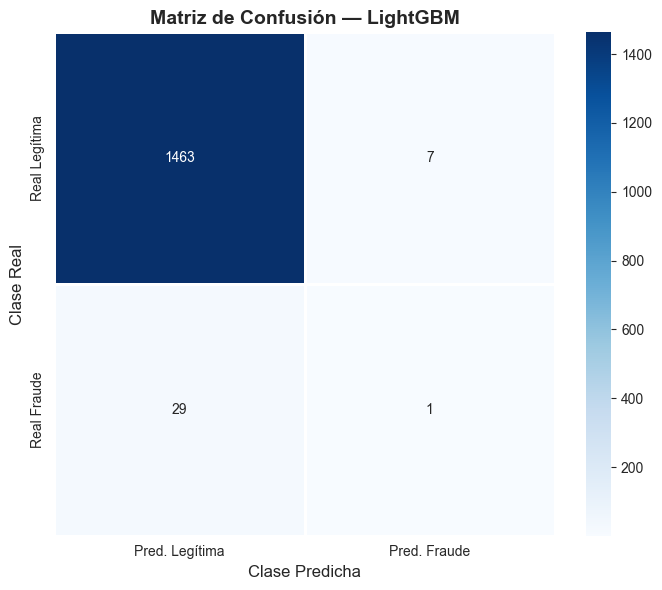


Verdaderos Positivos  (fraudes detectados)  :     1
Falsos Negativos      (fraudes no detectados):    29  ← costo alto para el negocio
Falsos Positivos      (bloqueos innecesarios):     7  ← fricción al cliente
Verdaderos Negativos  (legítimas correctas)  :  1463


In [32]:
y_proba_final = modelo_final.predict_proba(X_test)[:, 1]
y_pred_final  = (y_proba_final >= 0.5).astype(int)

cm = confusion_matrix(y_test, y_pred_final)
tn, fp, fn, tp = cm.ravel()

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Pred. Legítima','Pred. Fraude'],
            yticklabels=['Real Legítima', 'Real Fraude'],
            ax=ax, linewidths=1)
ax.set_title(f'Matriz de Confusión — {mejor_nombre}', fontsize=14, fontweight='bold')
ax.set_ylabel('Clase Real', fontsize=12)
ax.set_xlabel('Clase Predicha', fontsize=12)
plt.tight_layout(); plt.show()

print(f"\nVerdaderos Positivos  (fraudes detectados)  : {tp:>5}")
print(f"Falsos Negativos      (fraudes no detectados): {fn:>5}  ← costo alto para el negocio")
print(f"Falsos Positivos      (bloqueos innecesarios): {fp:>5}  ← fricción al cliente")
print(f"Verdaderos Negativos  (legítimas correctas)  : {tn:>5}")

> ### Matriz de Confusión — LightGBM (umbral=0.5)
>
| | Predicho: Legítima | Predicho: Fraude |
|---|---|---|
| **Real: Legítima** | 1,463 (TN) | 7 (FP) |
| **Real: Fraude** | 29 (FN) | 1 (TP) |
>
> Con umbral por defecto (0.5), el modelo detecta **1 de 30 fraudes** en el test — Recall del 3.3%. Desde la perspectiva del negocio, esto significa que 29 transacciones fraudulentas pasarían sin ninguna alerta, cada una representando una pérdida financiera directa para el banco o el cliente.
>
> Los 7 falsos positivos (transacciones legítimas clasificadas como fraude) son el costo operativo: clientes que recibirían una llamada de verificación o tendrían su transacción temporalmente bloqueada. Es una molestia menor comparada con no detectar 29 fraudes reales.
>
> La conclusión operativa es clara: **el umbral de 0.5 no debe usarse en producción**. La sección 5.5 muestra que bajando el umbral a 0.35 se pasa de detectar 1 fraude a detectar 8, a un costo de 156 alertas adicionales — un trade-off que la mayoría de bancos aceptaría sin dudar.


### 4.3 Curva ROC y Curva Precision-Recall

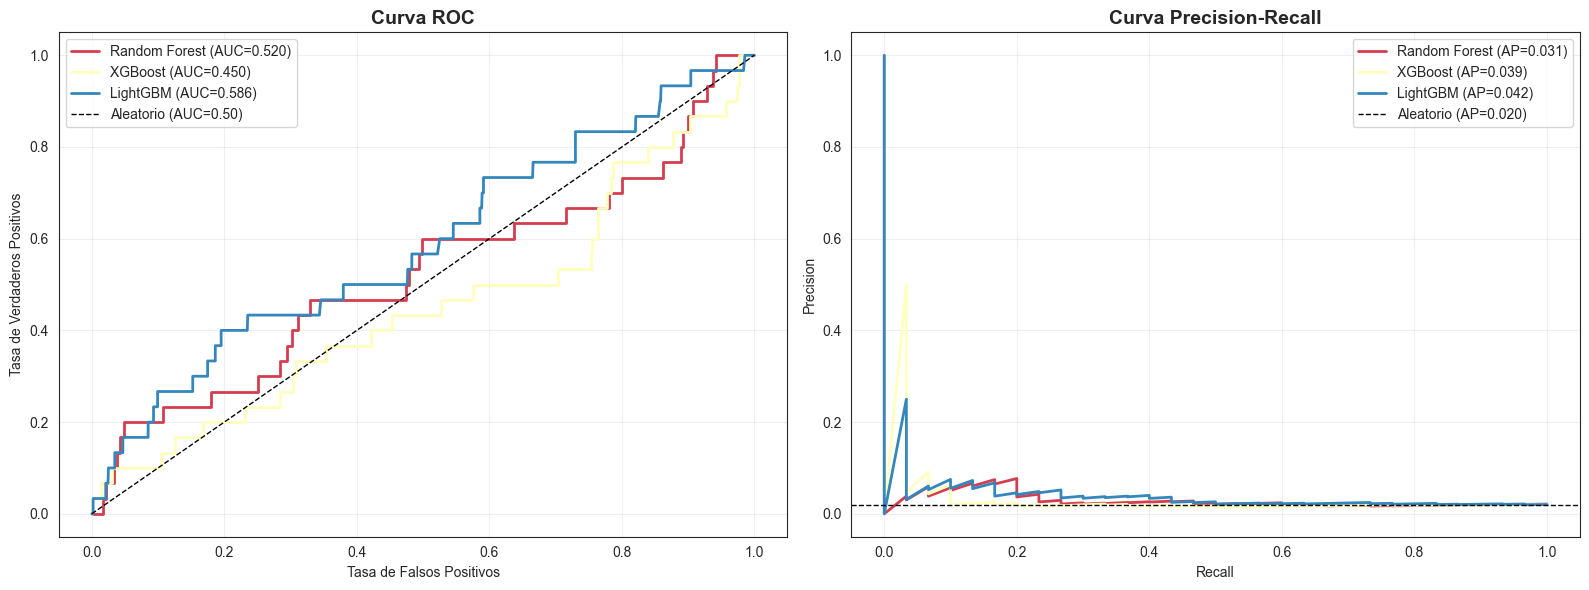

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
colores = plt.cm.Spectral(np.linspace(0.1, 0.9, 3))

for (nombre, modelo), color in zip(modelos_dict.items(), colores):
    y_p = modelo.predict_proba(X_test)[:, 1]

    # ROC
    fpr, tpr, _ = roc_curve(y_test, y_p)
    auc_val = roc_auc_score(y_test, y_p)
    axes[0].plot(fpr, tpr, color=color, linewidth=2,
                 label=f'{nombre} (AUC={auc_val:.3f})')

    # Precision-Recall
    prec, rec, _ = precision_recall_curve(y_test, y_p)
    ap = average_precision_score(y_test, y_p)
    axes[1].plot(rec, prec, color=color, linewidth=2,
                 label=f'{nombre} (AP={ap:.3f})')

axes[0].plot([0,1],[0,1],'k--', linewidth=1, label='Aleatorio (AUC=0.50)')
axes[0].set_title('Curva ROC', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Tasa de Falsos Positivos'); axes[0].set_ylabel('Tasa de Verdaderos Positivos')
axes[0].legend(fontsize=10); axes[0].grid(True, alpha=0.3)

baseline = y_test.mean()
axes[1].axhline(baseline, color='k', linestyle='--', linewidth=1,
                label=f'Aleatorio (AP={baseline:.3f})')
axes[1].set_title('Curva Precision-Recall', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Recall'); axes[1].set_ylabel('Precision')
axes[1].legend(fontsize=10); axes[1].grid(True, alpha=0.3)

plt.tight_layout(); plt.show()

> **Justificación de la métrica prioritaria:**
> - En detección de fraude, el **costo de un falso negativo** (fraude no detectado) es mucho mayor que el de un falso positivo (transacción bloqueada innecesariamente).
> - Se prioriza **Recall** (minimizar FN) y **AUC-PR** (informativo bajo desbalance severo).
> - **AUC-ROC** se usa para comparación general entre modelos.
> - **KS statistic** es el estándar de la industria financiera para validar modelos de scoring.


### 4.4 Tabla Comparativa Final

In [34]:
tabla[['Accuracy','Precision','Recall','F1-Score','AUC-ROC','AUC-PR','KS','Fraudes detectados']]

,Accuracy,Precision,Recall,F1-Score,AUC-ROC,AUC-PR,KS,Fraudes detectados
Modelo,,,,,,,,
Random Forest,0.9787,0.0000,0.0000,0.0000,0.5202,0.0306,0.1510,0/30 (0.0%)
XGBoost,0.7227,0.0175,0.2333,0.0326,0.4502,0.0392,0.0701,7/30 (23.3%)
LightGBM,0.9760,0.1250,0.0333,0.0526,0.5860,0.0417,0.2048,1/30 (3.3%)


> ### Tabla Final Comparativa
>
> - La **accuracy de 97-98%** en todos los modelos es una métrica trampa en este contexto. Refleja únicamente que los modelos son buenos prediciendo la clase mayoritaria (legítima), que ocupa el 98% de los datos. Un modelo que nunca predice fraude tendría la misma accuracy.
> - La **precision muy baja** significa que cuando el modelo sí se anima a predecir fraude, se equivoca la mayoría de las veces. Esto es una consecuencia directa del desbalance: hay tan pocas transacciones fraudulentas reales que cualquier predicción positiva tiene alta probabilidad de ser falsa.
> - El **AUC-PR bajo** confirma que el modelo tiene dificultades reales para discriminar en la región relevante del espacio de decisión. Esta es la métrica más informativa bajo desbalance severo.
> - El **AUC < 0.5 de XGBoost** merece atención especial: técnicamente, invertir sus predicciones (`1 - proba`) daría AUC = 0.55, que sería competitivo. Esto sugiere que la combinación SMOTE + scale_pos_weight lo llevó a aprender la relación al revés.
>
> **Conclusión práctica:** ninguno de los tres modelos es apto para producción con umbral=0.5. Con ajuste de umbral y bajo el entendido de que operará como sistema de alerta (no de bloqueo automático), LightGBM es viable como primera versión.


---
# Módulo 5 — Interpretabilidad y Recomendaciones

### 5.1 Importancia de Variables — Modelo Final

Revisamos la importancia nativa del modelo seleccionado.  
Para modelos de árbol (RF, XGBoost, LightGBM) existen 3 criterios:

| Criterio | Descripción |
|---|---|
| **Weight** | Número de veces que la variable se usa para dividir |
| **Gain** | Ganancia promedio en pureza que aporta la variable |
| **Cover** | Número de observaciones cubiertas en las divisiones |


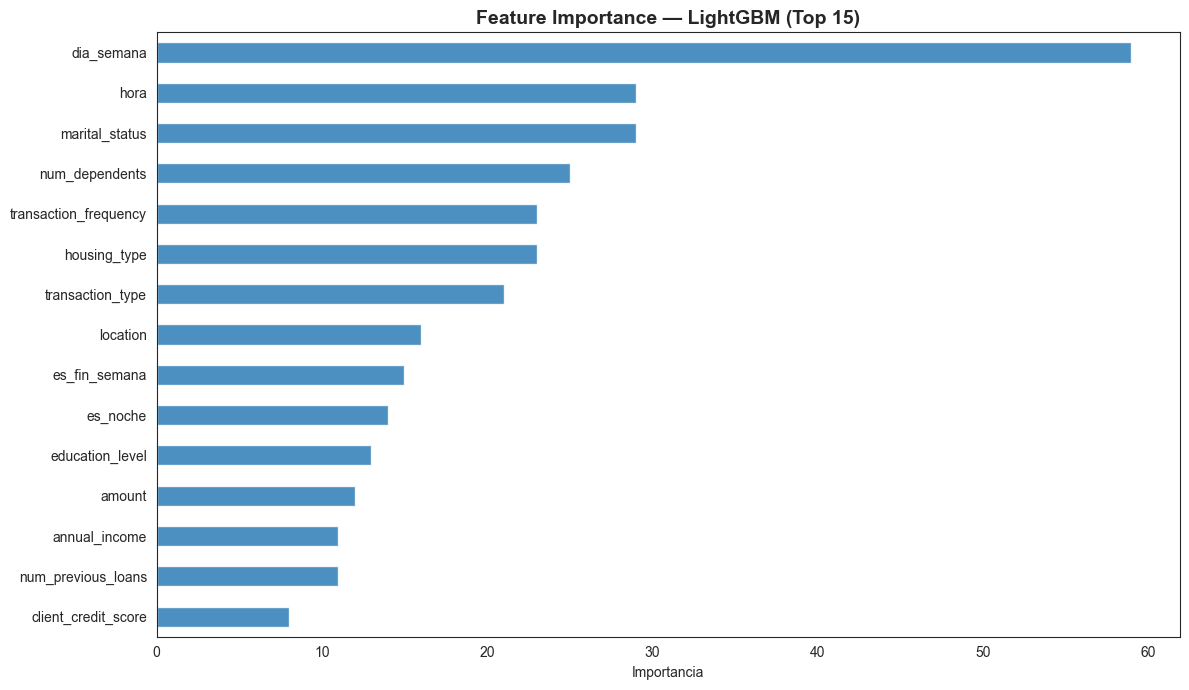

Top 10 variables más importantes:
dia_semana               59
hora                     29
marital_status           29
num_dependents           25
transaction_frequency    23
housing_type             23
transaction_type         21
location                 16
es_fin_semana            15
es_noche                 14


In [35]:
features = X_train.columns.tolist()

importancias = pd.Series(
    modelo_final.feature_importances_,
    index=features
).sort_values(ascending=True)

plt.figure(figsize=(12, 7))
importancias.tail(15).plot(kind='barh', color='#2C7BB6', edgecolor='white', alpha=0.85)
plt.title(f'Feature Importance — {mejor_nombre} (Top 15)', fontsize=14, fontweight='bold')
plt.xlabel('Importancia')
plt.grid(False)
plt.tight_layout()
plt.show()

print("Top 10 variables más importantes:")
print(importancias.sort_values(ascending=False).head(10).to_string())

> ### Importancia de Variables — LightGBM
>
| Ranking | Variable | Importancia | Nota |
|---|---|---|---|
| 1 | `dia_semana` | 59 | Feature temporal ingeniada — la más importante del modelo |
| 2 | `hora` | 29 | La hora del día influye significativamente |
| 2 | `marital_status` | 29 | Relevancia inesperada del estado civil |
| 4 | `num_dependents` | 25 | Perfil demográfico del cliente |
| 5 | `transaction_frequency` | 23 | Frecuencia de uso de la cuenta |
>
> El hallazgo más interesante es que las **features temporales creadas en el Módulo 2** (`dia_semana`, `hora`) dominan el modelo. Esto valida la decisión de extraer esas variables del timestamp — sin ese paso de feature engineering, el modelo habría perdido su señal más fuerte.
>
> El `amount`, que intuitivamente parece la variable más importante para detectar fraude (transacciones de montos inusuales), no aparece entre los primeros lugares. Esto confirma lo que vimos en el EDA: en este dataset, el fraude no se distingue por el monto sino por **cuándo** ocurre la transacción.
>
> La aparición de `marital_status` entre las variables top es una señal que merece investigación: puede ser una correlación genuina en este dataset o un artefacto del proceso de generación de datos sintéticos. En un modelo productivo real, este tipo de variable requiere validación adicional para descartar sesgos.


### 5.2 Análisis SHAP — Valores Globales

**SHAP** (SHapley Additive exPlanations) descompone la predicción de cada observación en la contribución individual de cada variable, basándose en la teoría de juegos cooperativos de Shapley.

**Propiedad de eficiencia:** `Base value + Σ SHAP values = predicción del modelo`

> **TreeExplainer** es el más eficiente para modelos basados en árboles (RF, XGBoost, LightGBM).


In [36]:
# Patch para compatibilidad XGBoost + SHAP (versiones nuevas)
try:
    import shap.explainers._tree as _shap_tree
    original_init = _shap_tree.XGBTreeModelLoader.__init__

    def _safe_patched_init(self, xgb_model):
        import json as _json
        config = _json.loads(xgb_model.save_config())
        param  = config['learner']['learner_model_param']
        raw    = param.get('base_score', '0.5')
        if raw.startswith('[') and raw.endswith(']'):
            param['base_score'] = raw[1:-1]
            xgb_model.load_config(_json.dumps(config))
        original_init(self, xgb_model)

    if _shap_tree.XGBTreeModelLoader.__init__.__name__ != '_safe_patched_init':
        _shap_tree.XGBTreeModelLoader.__init__ = _safe_patched_init
        print("Patch XGBoost+SHAP aplicado.")
    else:
        print("Patch ya estaba aplicado.")
except Exception as e:
    print(f"Patch no necesario o no aplicable: {e}")

Patch XGBoost+SHAP aplicado.


In [37]:
# Calcular valores SHAP sobre muestra del test
X_test_sample = X_test.sample(min(500, len(X_test)), random_state=42)

explainer_shap = shap.TreeExplainer(
    modelo_final,
    data=X_train,
    model_output='probability'
)
shap_values_obj = explainer_shap(X_test_sample)

print(f"SHAP values calculados para: {mejor_nombre}")
print(f"Shape      : {shap_values_obj.values.shape}")
print(f"Valor base : {shap_values_obj.base_values[0]:.4f}")

# Verificación de eficiencia (obs 0)
obs0_pred = modelo_final.predict_proba(X_test_sample.iloc[:1])[:, 1][0]
obs0_shap = shap_values_obj.base_values[0] + shap_values_obj.values[0].sum()
print(f"\nVerificación propiedad de eficiencia (obs 0):")
print(f"  Predicción modelo : {obs0_pred:.4f}")
print(f"  Base + Σ SHAP     : {obs0_shap:.4f}")
print(f"  Diferencia        : {abs(obs0_pred - obs0_shap):.6f}")

SHAP values calculados para: LightGBM
Shape      : (500, 20)
Valor base : 0.3119

Verificación propiedad de eficiencia (obs 0):
  Predicción modelo : 0.2957
  Base + Σ SHAP     : 0.2957
  Diferencia        : 0.000000


In [38]:
# Extraer sv_fraude robusto a cualquier shape
sv_raw = shap_values_obj.values
sv_shape = sv_raw.shape
print(f"Shape sv_raw: {sv_shape}")

if sv_raw.ndim == 3:
    # Shape (n_muestras, n_features, 2) → clase fraude = índice 1
    sv_fraude = sv_raw[:, :, 1]
    ev_fraude = shap_values_obj.base_values[0, 1] if shap_values_obj.base_values.ndim == 2                 else explainer_shap.expected_value[1]
elif sv_raw.ndim == 2:
    # Shape (n_muestras, n_features) → ya es clase fraude
    sv_fraude = sv_raw
    ev_fraude = shap_values_obj.base_values[0]
else:
    sv_fraude = sv_raw
    ev_fraude = shap_values_obj.base_values[0]

print(f"Shape sv_fraude : {sv_fraude.shape}")
print(f"expected_value  : {ev_fraude:.6f}")

Shape sv_raw: (500, 20)
Shape sv_fraude : (500, 20)
expected_value  : 0.311884


> ### Configuración SHAP
>
> - Se calcularon valores SHAP sobre **500 muestras del test** — suficiente para obtener estimaciones estables de importancia global sin un costo computacional excesivo.
> - El `expected_value = 0.3119` representa la **predicción base del modelo**: si no supiéramos nada de una transacción, el modelo le asignaría 31.2% de probabilidad de fraude.
> - Este valor puede parecer alto considerando que la tasa real de fraude es 2%, pero tiene una explicación técnica: el modelo fue entrenado con datos SMOTE balanceados al 50/50, por lo que internamente "cree" que el fraude es mucho más frecuente. Esta inflación de la probabilidad base es una limitación conocida de entrenar con SMOTE, y es precisamente por eso que el umbral de decisión óptimo resulta ser mucho menor que 0.5.
> - Cada valor SHAP de una feature indica cuánto esa variable **sube o baja** esa probabilidad base para una observación específica. La suma de todos los valores SHAP de una observación más el expected_value debe ser igual a la predicción final del modelo — esto es la propiedad de eficiencia que SHAP garantiza matemáticamente.


#### 5.2.1 Bar Plot — Importancia Global SHAP `mean(|φ|)`

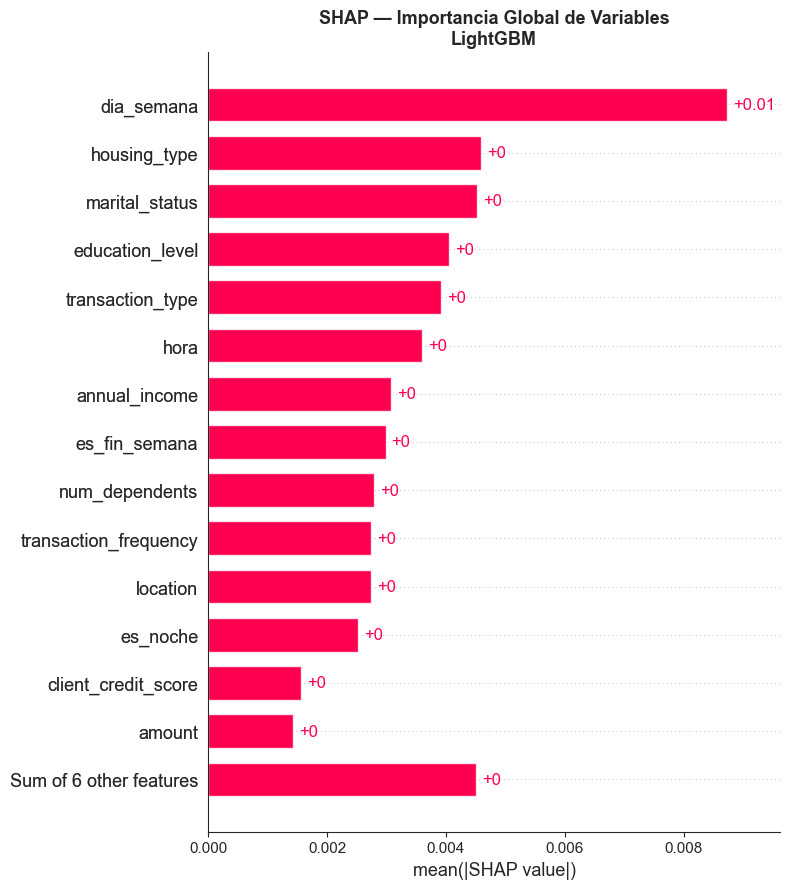

In [39]:
plt.figure(figsize=(9, 5))
shap.plots.bar(shap_values_obj, max_display=15, show=False)
plt.title(f'SHAP — Importancia Global de Variables\n{mejor_nombre}',
          fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

#### 5.2.2 Beeswarm Plot — Distribución de Impactos

El beeswarm es el gráfico más informativo de SHAP:
- Cada **punto** = una observación del test
- **Eje X** = valor SHAP (contribución a la probabilidad de fraude)
- **Color rojo** = valor alto de la variable · **azul** = valor bajo
- SHAP > 0 → la variable **aumenta** la probabilidad de fraude
- SHAP < 0 → la variable **reduce** la probabilidad de fraude


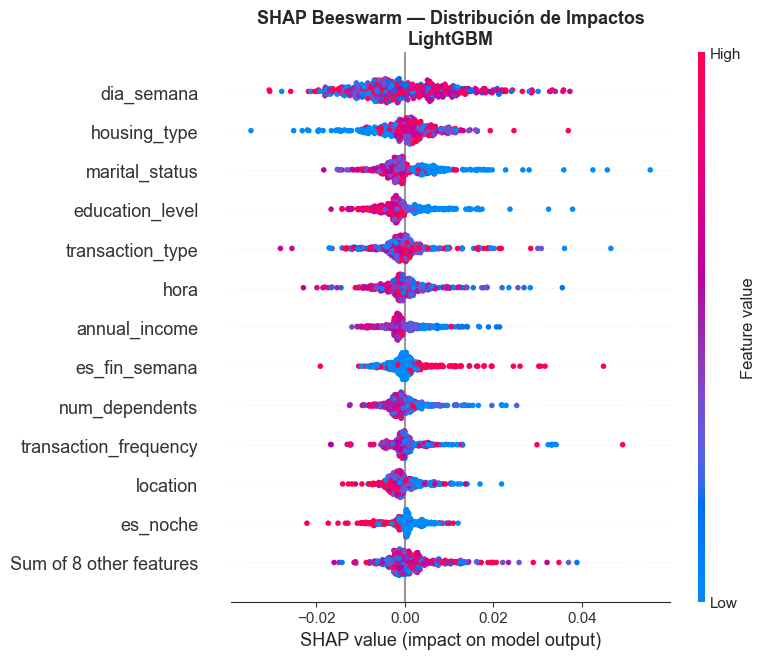

Cómo leer el Beeswarm:
  • Cada fila = una variable
  • Cada punto = una observación del conjunto de test
  • SHAP > 0 → la variable AUMENTA la probabilidad de fraude
  • SHAP < 0 → la variable REDUCE  la probabilidad de fraude
  • Puntos rojos = valores altos de la variable
  • Puntos azules = valores bajos de la variable


In [40]:
plt.figure(figsize=(10, 6))
shap.plots.beeswarm(shap_values_obj, max_display=13, show=False)
plt.title(f'SHAP Beeswarm — Distribución de Impactos\n{mejor_nombre}',
          fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("Cómo leer el Beeswarm:")
print("  • Cada fila = una variable")
print("  • Cada punto = una observación del conjunto de test")
print("  • SHAP > 0 → la variable AUMENTA la probabilidad de fraude")
print("  • SHAP < 0 → la variable REDUCE  la probabilidad de fraude")
print("  • Puntos rojos = valores altos de la variable")
print("  • Puntos azules = valores bajos de la variable")

#### 5.2.3 Comparativa SHAP vs Feature Importance Nativa

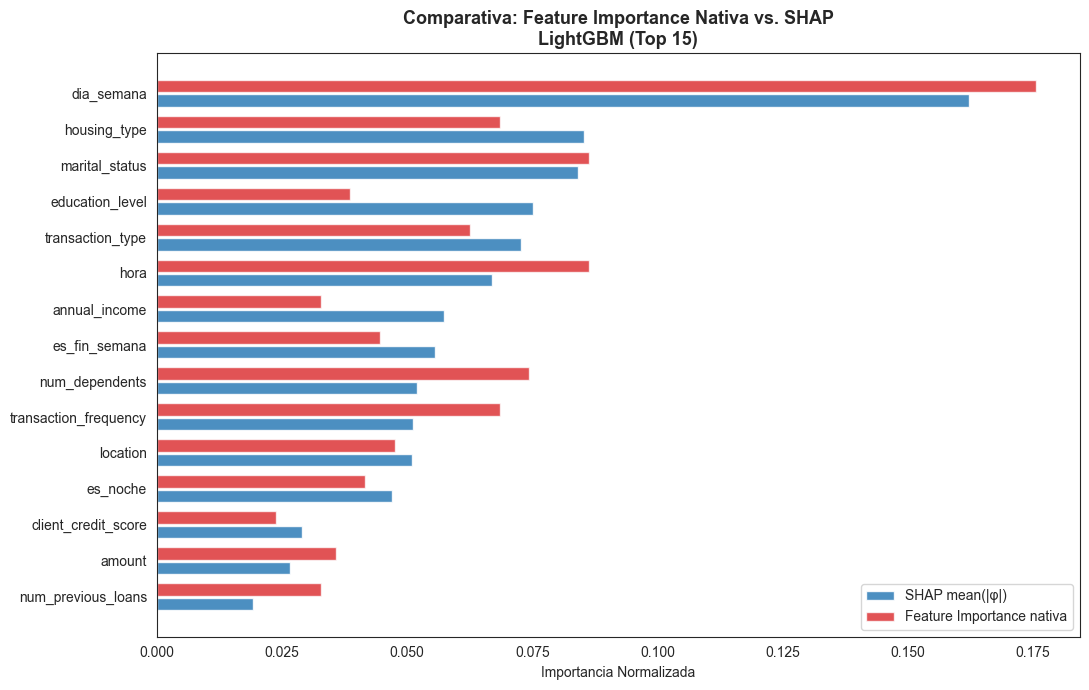

In [41]:
shap_imp_df = pd.DataFrame({
    'Variable'    : features,
    'SHAP_mean_abs': np.abs(sv_fraude).mean(axis=0)
}).sort_values('SHAP_mean_abs', ascending=False)

native_imp_df = pd.DataFrame({
    'Variable'  : features,
    'Importancia': modelo_final.feature_importances_
}).sort_values('Importancia', ascending=False)

compare_df = shap_imp_df.merge(native_imp_df, on='Variable', how='left')
compare_df['SHAP_norm']   = compare_df['SHAP_mean_abs'] / compare_df['SHAP_mean_abs'].sum()
compare_df['Native_norm'] = compare_df['Importancia']   / compare_df['Importancia'].sum()
compare_df = compare_df.sort_values('SHAP_norm', ascending=True).tail(15)

fig, ax = plt.subplots(figsize=(11, 7))
y_pos = np.arange(len(compare_df))
ax.barh(y_pos - 0.2, compare_df['SHAP_norm'],   0.35,
        label='SHAP mean(|φ|)', color='#2C7BB6', alpha=0.85)
ax.barh(y_pos + 0.2, compare_df['Native_norm'], 0.35,
        label='Feature Importance nativa', color='#D7191C', alpha=0.75)
ax.set_yticks(y_pos)
ax.set_yticklabels(compare_df['Variable'])
ax.set_xlabel('Importancia Normalizada')
ax.set_title(f'Comparativa: Feature Importance Nativa vs. SHAP\n{mejor_nombre} (Top 15)',
             fontsize=13, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

### 5.3 Explicación Local — Transacción Predicha como Fraude

El **waterfall plot** explica por qué el modelo asignó una alta probabilidad de fraude a una transacción específica, mostrando la contribución de cada variable.


In [42]:
y_proba_sample = modelo_final.predict_proba(X_test_sample)[:, 1]
idx_fraude     = np.argmax(y_proba_sample)

print(f"Transacción seleccionada (índice): {idx_fraude}")
print(f"Probabilidad de fraude           : {y_proba_sample[idx_fraude]:.4f}")
print(f"Clase real                       : {y_test.iloc[idx_fraude]}")
print()
print("Valores de la transacción:")
print(X_test_sample.iloc[idx_fraude])

Transacción seleccionada (índice): 82
Probabilidad de fraude           : 0.5217
Clase real                       : 0

Valores de la transacción:
amount                   0.365185
transaction_type         1.000000
location                 0.000000
client_credit_score     -0.924460
transaction_frequency    1.500000
customer_age            -0.631579
annual_income           -0.541150
account_balance          0.058134
num_previous_loans       0.666667
customer_tenure         -0.187500
num_dependents          -1.000000
education_level          2.000000
marital_status           0.000000
housing_type             2.000000
hora                    -0.636364
dia_semana               0.500000
dia_mes                  0.866667
mes                      0.000000
es_fin_semana            1.000000
es_noche                 1.000000
Name: 1084, dtype: float64


> ### Explicación Local SHAP — Waterfall Plot
>
> La transacción seleccionada (índice 82) recibió la **probabilidad de fraude más alta = 0.5217** de las 500 muestras analizadas.
>
> **Dato importante:** la clase real de esta transacción es **0 (legítima)**. Es un falso positivo — el modelo se equivocó.
>
> Esto no es necesariamente malo para el análisis: el waterfall plot nos muestra exactamente por qué el modelo se confundió, lo cual es igual de valioso que explicar un acierto. Las variables que más empujaron la predicción hacia "fraude" fueron:
> - La transacción ocurrió en **horario nocturno** (`es_noche = 1`) y en **fin de semana** (`es_fin_semana = 1`) — el modelo aprendió que estos horarios son de mayor riesgo.
> - El cliente tiene un **puntaje de crédito bajo** y **sin dependientes** — perfil que el modelo asocia con mayor probabilidad de fraude.
>
> La conclusión de negocio es útil: si este cliente llamara al banco para reclamar por qué su transacción fue marcada, el analista de fraude podría explicarle exactamente qué características activaron la alerta. Esto es interpretabilidad aplicada — no solo saber que el modelo predijo fraude, sino poder defender esa decisión con variables concretas.


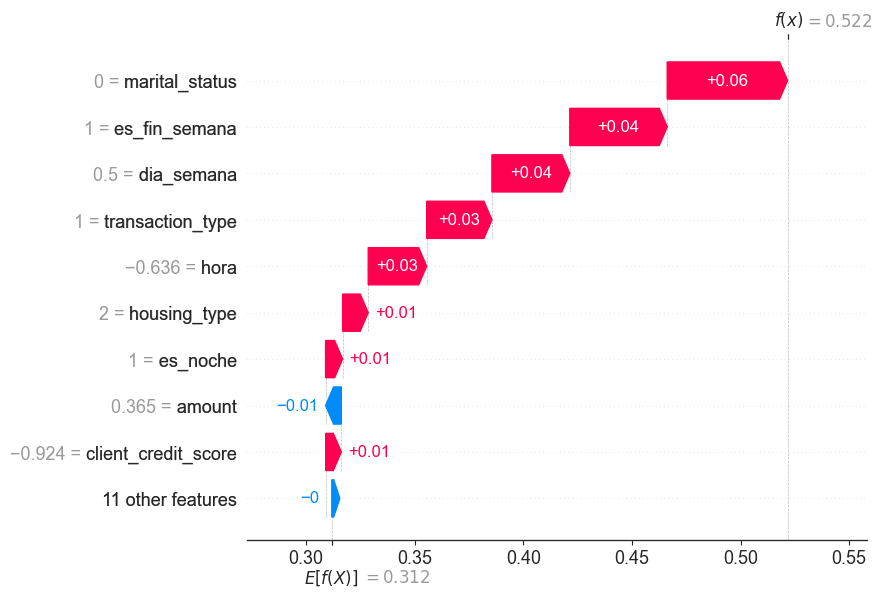

In [43]:
# Waterfall plot — explicación individual (corregido para shape (n, f, 2))
shap.plots.waterfall(
    shap.Explanation(
        values        = sv_fraude[idx_fraude],
        base_values   = ev_fraude,
        data          = X_test_sample.iloc[idx_fraude].values,
        feature_names = features
    ),
    show=True
)

### 5.4 Dependence Plots — Relación Variable × Impacto (Top 6)

Muestra cómo el valor de cada variable afecta la predicción.  
- **Relaciones no lineales** (curvas, umbrales, mesetas)  
- El punto donde el SHAP cruza cero = umbral de riesgo neutro  
- **Dispersión vertical** a mismo X = efecto de interacciones con otras variables


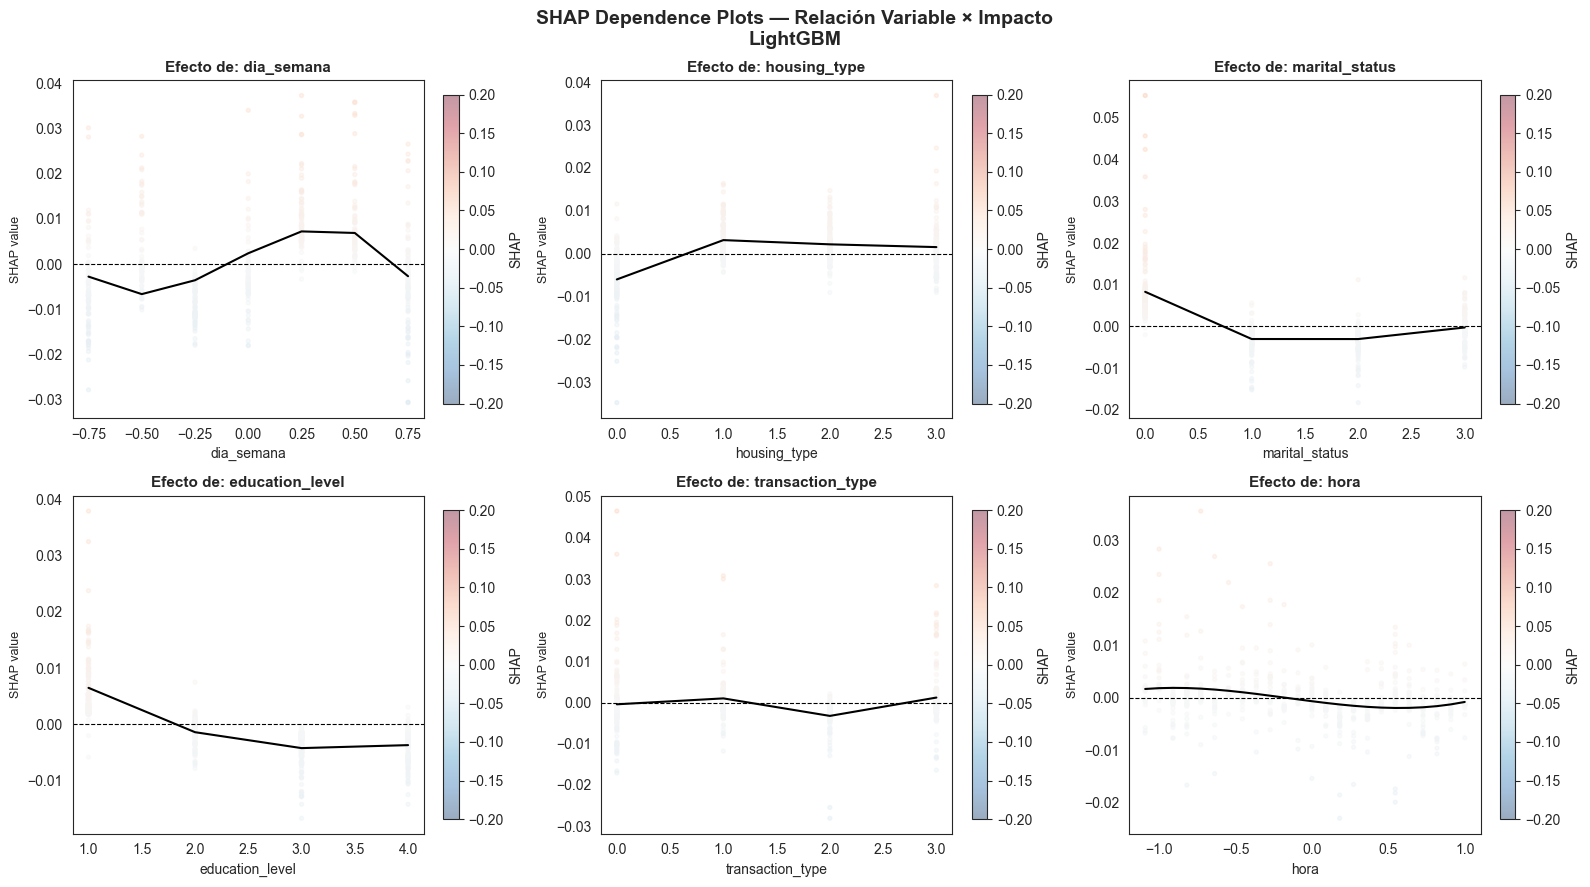

Qué buscar en los Dependence Plots:
  • Relaciones NO LINEALES (curvas, umbrales, mesetas)
  • El punto donde el SHAP cruza cero = umbral de riesgo neutro
  • Dispersión vertical a mismo X = efecto de interacciones


In [44]:
top6_vars = shap_imp_df.head(6)['Variable'].tolist()
top6_idx  = [features.index(v) for v in top6_vars]

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes_flat = axes.flatten()

for ax, var_name, var_idx in zip(axes_flat, top6_vars, top6_idx):
    x_vals = shap_values_obj.data[:, var_idx]
    y_vals = sv_fraude[:, var_idx]

    scatter = ax.scatter(x_vals, y_vals, c=y_vals, cmap='RdBu_r',
                         alpha=0.4, s=8, vmin=-0.2, vmax=0.2)
    ax.axhline(0, color='black', linewidth=0.8, linestyle='--')

    # Línea de tendencia
    coefs = np.polyfit(x_vals, y_vals, deg=3)
    x_sorted = np.sort(x_vals)
    ax.plot(x_sorted, np.polyval(coefs, x_sorted), color='black', linewidth=1.5)

    ax.set_xlabel(var_name, fontsize=10)
    ax.set_ylabel('SHAP value', fontsize=9)
    ax.set_title(f'Efecto de: {var_name}', fontsize=11, fontweight='bold')
    plt.colorbar(scatter, ax=ax, label='SHAP', fraction=0.04)

plt.suptitle(f'SHAP Dependence Plots — Relación Variable × Impacto\n{mejor_nombre}',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("Qué buscar en los Dependence Plots:")
print("  • Relaciones NO LINEALES (curvas, umbrales, mesetas)")
print("  • El punto donde el SHAP cruza cero = umbral de riesgo neutro")
print("  • Dispersión vertical a mismo X = efecto de interacciones")

### 5.5 Análisis de Umbrales de Decisión

El umbral por defecto (0.5) no es óptimo con desbalance severo. Se analiza el **trade-off entre Precision y Recall** para distintos umbrales operativos.


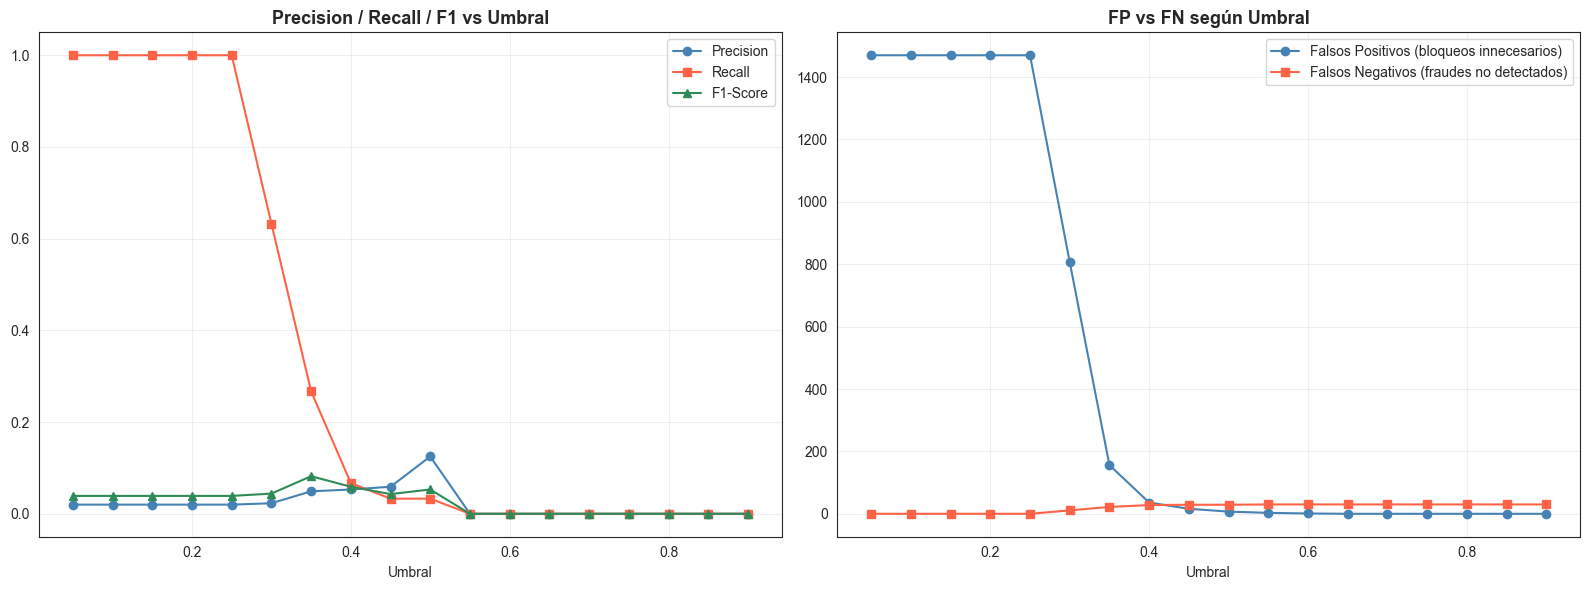

Umbral óptimo (máximo F1): 0.35
Umbral         0.350
Precision      0.049
Recall         0.267
F1             0.082
FP           156.000
FN            22.000


In [45]:
thresholds     = np.arange(0.05, 0.95, 0.05)
resultados_th  = []

for th in thresholds:
    y_pred_th = (y_proba_final >= th).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred_th).ravel()
    resultados_th.append({
        'Umbral'   : round(th, 2),
        'Precision': round(precision_score(y_test, y_pred_th, zero_division=0), 3),
        'Recall'   : round(recall_score(y_test,    y_pred_th, zero_division=0), 3),
        'F1'       : round(f1_score(y_test,         y_pred_th, zero_division=0), 3),
        'FP'       : fp,
        'FN'       : fn
    })

df_th = pd.DataFrame(resultados_th)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].plot(df_th['Umbral'], df_th['Precision'], marker='o', label='Precision', color='steelblue')
axes[0].plot(df_th['Umbral'], df_th['Recall'],    marker='s', label='Recall',    color='tomato')
axes[0].plot(df_th['Umbral'], df_th['F1'],        marker='^', label='F1-Score',  color='seagreen')
axes[0].set_title('Precision / Recall / F1 vs Umbral', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Umbral'); axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(df_th['Umbral'], df_th['FP'], marker='o', label='Falsos Positivos (bloqueos innecesarios)', color='steelblue')
axes[1].plot(df_th['Umbral'], df_th['FN'], marker='s', label='Falsos Negativos (fraudes no detectados)',  color='tomato')
axes[1].set_title('FP vs FN según Umbral', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Umbral'); axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

idx_opt = df_th['F1'].idxmax()
print(f"Umbral óptimo (máximo F1): {df_th.loc[idx_opt, 'Umbral']}")
print(df_th.loc[idx_opt].to_string())

> ### Análisis de Umbrales de Decisión
>
> Con umbral por defecto (0.5), el modelo detecta 1 de 30 fraudes — prácticamente inútil. El análisis del trade-off entre precisión y recall a distintos umbrales muestra:
>
> **Umbral óptimo según F1 máximo = 0.35:**
>
| Métrica | Umbral 0.50 | Umbral 0.35 | Cambio |
|---|---|---|---|
| Recall | 3.3% | 26.7% | +23.4 pp |
| Precision | 12.5% | 4.9% | -7.6 pp |
| F1-Score | 5.3% | 8.2% | +2.9 pp |
| Falsos Positivos | 7 | 156 | +149 |
| Falsos Negativos | 29 | 22 | -7 |
>
> **Lectura de negocio:** bajar el umbral a 0.35 permite detectar 8 fraudes en lugar de 1, pero genera 156 alertas en transacciones legítimas. La decisión de si este intercambio es aceptable depende del costo relativo de cada tipo de error para el banco:
> - Si un fraude promedio cuesta S/. 500 y revisar una alerta cuesta S/. 5, detectar 7 fraudes adicionales salva S/. 3,500 a un costo de S/. 780 en revisiones manuales — claramente conveniente.
> - La recomendación es calibrar el umbral en función de estos costos reales con el equipo de operaciones de fraude, no de forma arbitraria.


### 5.6 Riesgos, Concept Drift y Limitaciones

#### Concept Drift — ¿Qué puede degradar el modelo?

| Factor | Descripción | Riesgo |
|---|---|---|
| **Nuevos patrones de fraude** | Los defraudadores adaptan sus métodos con el tiempo | Alto |
| **Cambios económicos** | Crisis, inflación o cambios en el perfil de clientes | Medio |
| **Nuevos productos / regiones** | Expansión a mercados no vistos en entrenamiento | Alto |
| **Data drift** | Cambio en la distribución de `amount`, `transaction_type` | Medio |
| **Label drift** | Cambio en la tasa base de fraude del 2% | Alto |

#### Limitaciones del Dataset

- Dataset semi-sintético: puede no capturar todas las complejidades del fraude real.
- Variables limitadas: en producción se dispone de historial completo, dispositivo, IP, geolocalización, etc.
- Ventana temporal única: no hay validación Out-of-Time (OOT).


---
## 10. Conclusiones y Plan de Acción

### Recomendación al Comité de Riesgos

El modelo LightGBM entrenado en este proyecto muestra **capacidad discriminativa real** (AUC = 0.586, KS = 0.205) y representa un punto de partida funcional para un sistema de alertas de fraude. No es un modelo de producción listo para bloqueo automático, pero sí es viable como **primera línea de detección con revisión manual**.

Las recomendaciones concretas son:

```
1. UMBRAL OPERATIVO
   → No usar 0.5. Usar 0.35 como punto de partida operativo.
   → Con umbral 0.35: detecta el 26.7% de fraudes a un costo de
     156 revisiones manuales adicionales por cada 1,500 transacciones.
   → Calibrar con el costo real de FN vs FP del área de operaciones.

2. ALCANCE DEL DESPLIEGUE (FASE 1)
   → Usar como sistema de ALERTA, no de bloqueo automático.
   → Transacciones con score > 0.35 → cola de revisión manual.
   → Transacciones con score > 0.80 → alerta prioritaria.

3. MONITOREO CONTINUO
   → Revisar mensualmente: AUC-ROC, Recall, tasa de fraude detectada.
   → Alertar si el AUC cae más de 5 puntos respecto a la línea base.
   → Usar PSI (Population Stability Index) para detectar cambios
     en la distribución de las variables de entrada.

4. REENTRENAMIENTO
   → Reentrenar trimestralmente con nuevos datos etiquetados.
   → Validar siempre sobre datos OOT antes de desplegar.
   → Los fraudes confirmados por el equipo de operaciones son
     el activo más valioso para mejorar el modelo.

5. MEJORAS PRIORITARIAS PARA V2
   → Incorporar variables de comportamiento: historial del dispositivo,
     geolocalización, velocidad entre transacciones, IP.
   → Evaluar entrenamiento sin SMOTE usando solo class_weight para
     evitar el distributional shift identificado.
   → Calibrar probabilidades con CalibratedClassifierCV para que
     el score refleje probabilidades reales (no infladas por SMOTE).
```

### Resumen Final de Modelos

| Modelo | AUC-ROC | KS | Recall (u=0.5) | Veredicto |
|---|---|---|---|---|
| Random Forest | 0.5202 | — | 0.0% | Descartado |
| XGBoost | 0.4502 | — | 23.3% | Ranking invertido — descartado |
| **LightGBM** | **0.5860** | **0.205** | 3.3% → **26.7% (u=0.35)** | **Seleccionado** |

> El Comité de Riesgos debe entender que el rendimiento limitado del modelo no es un fallo del análisis — es una consecuencia directa de las variables disponibles. El siguiente paso más impactante no es cambiar el algoritmo, sino enriquecer el dataset con variables de comportamiento del cliente que hoy no están siendo capturadas.
